In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import time

In [2]:
class Sigmoid:
    def forward(self, x):
        x_clipped = np.clip(x, -500, 500)
        return 1.0 / (1.0 + np.exp(-x_clipped))
    def derivative(self, x):
        return x * (1 - x)

class Linear:
    def forward(self, x):
        return x
    def derivative(self, output):
        return np.ones_like(output)

class ReLU:
    def forward(self, x):
        return np.maximum(0, x)
    
    def derivative(self, output):
        return (output > 0).astype(float)

class Tanh:
    def forward(self, x):
        self.output = np.tanh(x)
        return self.output
    
    def derivative(self, output):
        return 1.0 - output**2
    

In [3]:
class DenseLayer:
    def __init__(self, n_inputs, n_neurons, activation, init_method='xavier'):
        self.n_inputs = n_inputs
        self.n_neurons = n_neurons
        self.activation = activation
        self.initialize_weights(n_inputs, n_neurons, method=init_method)
        self.d_weights = np.zeros_like(self.weights)
        self.d_biases = np.zeros_like(self.biases)
        self.v_weights = np.zeros_like(self.weights)
        self.v_biases = np.zeros_like(self.biases)
        self.s_weights = np.zeros_like(self.weights)
        self.s_biases = np.zeros_like(self.biases)
        
    def set_weights(self, new_weights, new_biases):
        self.weights = new_weights
        self.biases = new_biases

    def initialize_weights(self, n_inputs, n_neurons, method='xavier'):
        if method == 'xavier':
            limit = np.sqrt(6.0 / (n_inputs + n_neurons))
            self.weights = np.random.uniform(-limit, limit, (n_inputs, n_neurons))
            self.biases = np.zeros((1, n_neurons))
            
        elif method == 'he':
            std = np.sqrt(2.0 / n_inputs)
            self.weights = np.random.randn(n_inputs, n_neurons) * std
            self.biases = np.zeros((1, n_neurons)) + 0.01

        elif method == 'random':
            self.weights = np.random.randn(n_inputs, n_neurons)
            self.biases = np.zeros((1, n_neurons))
    
    def forward(self, inputs):
        self.inputs = inputs
        self.z = np.dot(inputs, self.weights) + self.biases
        self.output = self.activation.forward(self.z)
        return self.output

    def backward_output(self, y_true):
        n_samples = y_true.shape[0]
        loss_derivative = 2.0 * (self.output - y_true) / n_samples
        self.delta = loss_derivative * self.activation.derivative(self.output)
        self.d_weights = np.dot(self.inputs.T, self.delta)
        self.d_biases = np.sum(self.delta, axis=0, keepdims=True)
        return np.dot(self.delta, self.weights.T)

    def backward_hidden(self, propagated_error):
        self.delta = propagated_error * self.activation.derivative(self.output)
        self.d_weights = np.dot(self.inputs.T, self.delta)
        self.d_biases = np.sum(self.delta, axis=0, keepdims=True)
        return np.dot(self.delta, self.weights.T)

    def update_weights(self, learning_rate, momentum=0.0, rmsprop_beta=0.0, epsilon=1e-8):
        if rmsprop_beta > 0.0:
            self.s_weights = (rmsprop_beta * self.s_weights) + ((1 - rmsprop_beta) * (self.d_weights ** 2))
            self.s_biases = (rmsprop_beta * self.s_biases) + ((1 - rmsprop_beta) * (self.d_biases ** 2))
            grad_w = self.d_weights / (np.sqrt(self.s_weights) + epsilon)
            grad_b = self.d_biases / (np.sqrt(self.s_biases) + epsilon)
        else:
            grad_w = self.d_weights
            grad_b = self.d_biases
        self.v_weights = (momentum * self.v_weights) + (learning_rate * grad_w)
        self.v_biases = (momentum * self.v_biases) + (learning_rate * grad_b)
        self.weights -= self.v_weights
        self.biases -= self.v_biases

In [4]:
class Scaler:
    def __init__(self):
        self.min_val = None
        self.max_val = None
        
    def fit(self, data):
        self.min_val = np.min(data, axis=0)
        self.max_val = np.max(data, axis=0)
        
    def transform(self, data):
        if self.min_val is None or self.max_val is None:
            raise ValueError("Skaler musi zostać najpierw dopasowany (użyj metody fit).")
        return (data - self.min_val) / (self.max_val - self.min_val + 1e-8)
        
    def inverse_transform(self, data_norm):
        if self.min_val is None or self.max_val is None:
            raise ValueError("Skaler musi zostać najpierw dopasowany (użyj metody fit).")
        return data_norm * (self.max_val - self.min_val + 1e-8) + self.min_val

In [5]:
class MLP:
    def __init__(self):
        self.layers = []
        self.input_scaler = None
        self.output_scaler = None
        
    def add_layer(self, layer):
        self.layers.append(layer)

    def set_scalers(self, input_scaler, output_scaler):
        self.input_scaler = input_scaler
        self.output_scaler = output_scaler
        
    def forward(self, X):
        out = X
        if self.input_scaler is not None:
            out = self.input_scaler.transform(X)
        for layer in self.layers:
            out = layer.forward(out)
        if self.output_scaler is not None:
            out = self.output_scaler.inverse_transform(out)
        return out
    
    def backward(self, y_true):
        last_layer = self.layers[-1]
        propagated_error = last_layer.backward_output(y_true)
        for layer in reversed(self.layers[:-1]):
            propagated_error = layer.backward_hidden(propagated_error)
            
    def update_weights(self, learning_rate, momentum=0.0, rmsprop_beta=0.0, epsilon=1e-8):
        for layer in self.layers:
            layer.update_weights(learning_rate, momentum, rmsprop_beta=rmsprop_beta, epsilon=epsilon)

### Wczytanie danych i trening z PyTorch

In [6]:
df_train1 = pd.read_csv('square-simple-training.csv', index_col=0)
df_test1 = pd.read_csv('square-simple-test.csv', index_col=0)
df_train2 = pd.read_csv('steps-large-training.csv', index_col=0)
df_test2 = pd.read_csv('steps-large-test.csv', index_col=0)

In [7]:
X_raw_train1 = df_train1[['x']].values
y_raw_train1 = df_train1[['y']].values
X_raw_train2 = df_train2[['x']].values
y_raw_train2 = df_train2[['y']].values
X_raw_test1 = df_test1[['x']].values
y_raw_test1 = df_test1[['y']].values
X_raw_test2 = df_test2[['x']].values
y_raw_test2 = df_test2[['y']].values

In [8]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_X.fit(X_raw_train1)
scaler_y.fit(y_raw_train1)

X_scaled = scaler_X.transform(X_raw_train1)
y_scaled = scaler_y.transform(y_raw_train1)

X_tensor_train1 = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor_train1 = torch.tensor(y_scaled, dtype=torch.float32)

X_scaled = scaler_X.transform(X_raw_test1)
y_scaled = scaler_y.transform(y_raw_test1)

X_tensor_test1 = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor_test1 = torch.tensor(y_scaled, dtype=torch.float32)

In [9]:
class PyTorchMLP_1x5(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_layer = nn.Linear(1, 5)
        self.activation = nn.Sigmoid()
        self.output_layer = nn.Linear(5, 1)

    def forward(self, x):
        x = self.hidden_layer(x)
        x = self.activation(x)
        x = self.output_layer(x)
        return x

model_1x5 = PyTorchMLP_1x5()

In [10]:
epochs = 5000  
learning_rate = 0.01

criterion = nn.MSELoss()
optimizer = optim.Adam(model_1x5.parameters(), lr=learning_rate)

for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model_1x5(X_tensor_train1)
    loss = criterion(predictions, y_tensor_train1)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 500 == 0:
        print(f'Epoka [{epoch+1}/{epochs}], Strata (MSE na znormalizowanych): {loss.item():.6f}')

Epoka [500/5000], Strata (MSE na znormalizowanych): 0.064450
Epoka [1000/5000], Strata (MSE na znormalizowanych): 0.005319
Epoka [1500/5000], Strata (MSE na znormalizowanych): 0.000265
Epoka [2000/5000], Strata (MSE na znormalizowanych): 0.000095
Epoka [2500/5000], Strata (MSE na znormalizowanych): 0.000061
Epoka [3000/5000], Strata (MSE na znormalizowanych): 0.000044
Epoka [3500/5000], Strata (MSE na znormalizowanych): 0.000034
Epoka [4000/5000], Strata (MSE na znormalizowanych): 0.000028
Epoka [4500/5000], Strata (MSE na znormalizowanych): 0.000025
Epoka [5000/5000], Strata (MSE na znormalizowanych): 0.000022


In [47]:
W_hidden_1x5 = model_1x5.hidden_layer.weight.data.detach().numpy().T
b_hidden_1x5 = model_1x5.hidden_layer.bias.data.detach().numpy().reshape(1, -1)

W_output_1x5 = model_1x5.output_layer.weight.data.detach().numpy().T
b_output_1x5 = model_1x5.output_layer.bias.data.detach().numpy().reshape(1, -1)

print("W_hidden = np.array(" + np.array2string(W_hidden_1x5, separator=',') + ")")
print("B_hidden = np.array(" + np.array2string(b_hidden_1x5, separator=',') + ")")
print("W_output = np.array(" + np.array2string(W_output_1x5, separator=',') + ")")
print("B_output = np.array(" + np.array2string(b_output_1x5, separator=',') + ")")

W_hidden = np.array([[-0.11752329,-4.450178  ,-0.2682571 ,-5.637457  , 5.8935103 ]])
B_hidden = np.array([[ 0.8567281 ,-0.81169575, 1.523709  ,-0.47331986,-5.539007  ]])
W_output = np.array([[-0.04147962],
 [ 0.6455535 ],
 [-0.18222372],
 [ 1.5742114 ],
 [ 2.0071092 ]])
B_output = np.array([[-0.0372127]])


In [48]:
model_1x5.eval()

with torch.no_grad():
    predictions_test = model_1x5(X_tensor_test1)

    test_mse = criterion(predictions_test, y_tensor_test1)
    
    print(f'MSE na zbiorze testowym (znormalizowane): {test_mse.item():.6f}')
predictions_test_np = predictions_test.numpy()
y_test_np = y_tensor_test1.numpy()

predictions_test_raw = scaler_y.inverse_transform(predictions_test_np)
y_test_raw = scaler_y.inverse_transform(y_test_np) 

test_mse_unscaled = mean_squared_error(y_test_raw, predictions_test_raw)

print(f'MSE na zbiorze testowym (nieznormalizowane / oryginalna skala): {test_mse_unscaled:.6f}')

MSE na zbiorze testowym (znormalizowane): 0.000033
MSE na zbiorze testowym (nieznormalizowane / oryginalna skala): 3.811631


In [49]:
class PyTorchMLP_1x10(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_layer = nn.Linear(1, 10)
        self.activation = nn.Sigmoid()
        self.output_layer = nn.Linear(10, 1)

    def forward(self, x):
        x = self.hidden_layer(x)
        x = self.activation(x)
        x = self.output_layer(x)
        return x

model_1x10 = PyTorchMLP_1x10()

In [50]:
epochs = 5000  
learning_rate = 0.01

criterion = nn.MSELoss()
optimizer = optim.Adam(model_1x10.parameters(), lr=learning_rate)

for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model_1x10(X_tensor_train1)
    loss = criterion(predictions, y_tensor_train1)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 500 == 0:
        print(f'Epoka [{epoch+1}/{epochs}], Strata (MSE na znormalizowanych): {loss.item():.6f}')

Epoka [500/5000], Strata (MSE na znormalizowanych): 0.000383
Epoka [1000/5000], Strata (MSE na znormalizowanych): 0.000138
Epoka [1500/5000], Strata (MSE na znormalizowanych): 0.000054
Epoka [2000/5000], Strata (MSE na znormalizowanych): 0.000011
Epoka [2500/5000], Strata (MSE na znormalizowanych): 0.000009
Epoka [3000/5000], Strata (MSE na znormalizowanych): 0.000005
Epoka [3500/5000], Strata (MSE na znormalizowanych): 0.000003
Epoka [4000/5000], Strata (MSE na znormalizowanych): 0.000002
Epoka [4500/5000], Strata (MSE na znormalizowanych): 0.000002
Epoka [5000/5000], Strata (MSE na znormalizowanych): 0.000011


In [51]:
W_hidden_1x10 = model_1x10.hidden_layer.weight.data.detach().numpy().T
b_hidden_1x10 = model_1x10.hidden_layer.bias.data.detach().numpy().reshape(1, -1)

W_output_1x10 = model_1x10.output_layer.weight.data.detach().numpy().T
b_output_1x10 = model_1x10.output_layer.bias.data.detach().numpy().reshape(1, -1)

print("W_hidden = np.array(" + np.array2string(W_hidden_1x10, separator=',') + ")")
print("B_hidden = np.array(" + np.array2string(b_hidden_1x10, separator=',') + ")")
print("W_output = np.array(" + np.array2string(W_output_1x10, separator=',') + ")")
print("B_output = np.array(" + np.array2string(b_output_1x10, separator=',') + ")")

W_hidden = np.array([[-3.4661021e+00,-2.6580348e+00,-3.1332178e+00,-4.7329741e+00,
   8.8288881e-02,-1.5005876e+00,-3.9736192e+00,-2.6892009e-03,
   5.4330719e-01, 2.5630039e-01]])
B_hidden = np.array([[-0.99598956,-0.96162707, 2.120613  , 5.1229534 , 1.2910765 ,-0.49364612,
  -0.9276161 , 1.0231488 ,-0.0599241 ,-0.03135268]])
W_output = np.array([[ 1.3211429 ],
 [ 0.9291948 ],
 [-0.85892373],
 [-2.63222   ],
 [ 0.9381545 ],
 [ 0.7022172 ],
 [ 1.8646412 ],
 [ 1.0760785 ],
 [ 0.3419954 ],
 [ 0.3701033 ]])
B_output = np.array([[0.69911975]])


In [52]:
model_1x10.eval()

with torch.no_grad():
    predictions_test = model_1x10(X_tensor_test1)

    test_mse = criterion(predictions_test, y_tensor_test1)
    
    print(f'MSE na zbiorze testowym (znormalizowane): {test_mse.item():.6f}')
predictions_test_np = predictions_test.numpy()
y_test_np = y_tensor_test1.numpy()

predictions_test_raw = scaler_y.inverse_transform(predictions_test_np)
y_test_raw = scaler_y.inverse_transform(y_test_np) 

test_mse_unscaled = mean_squared_error(y_test_raw, predictions_test_raw)

print(f'MSE na zbiorze testowym (nieznormalizowane / oryginalna skala): {test_mse_unscaled:.6f}')

MSE na zbiorze testowym (znormalizowane): 0.000004
MSE na zbiorze testowym (nieznormalizowane / oryginalna skala): 0.445572


In [53]:
class PyTorchMLP_2x5(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_layer1 = nn.Linear(1, 5)
        self.hidden_layer2 = nn.Linear(5, 5)
        self.activation = nn.Sigmoid()
        self.output_layer = nn.Linear(5, 1)

    def forward(self, x):
        x = self.hidden_layer1(x)
        x = self.activation(x)
        x = self.hidden_layer2(x)
        x = self.activation(x)
        x = self.output_layer(x)
        return x

model_2x5 = PyTorchMLP_2x5()

In [54]:
epochs = 5000  
learning_rate = 0.01

criterion = nn.MSELoss()
optimizer = optim.Adam(model_2x5.parameters(), lr=learning_rate)

for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model_2x5(X_tensor_train1)
    loss = criterion(predictions, y_tensor_train1)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 500 == 0:
        print(f'Epoka [{epoch+1}/{epochs}], Strata (MSE na znormalizowanych): {loss.item():.6f}')

Epoka [500/5000], Strata (MSE na znormalizowanych): 0.000029
Epoka [1000/5000], Strata (MSE na znormalizowanych): 0.000012
Epoka [1500/5000], Strata (MSE na znormalizowanych): 0.000009
Epoka [2000/5000], Strata (MSE na znormalizowanych): 0.000007
Epoka [2500/5000], Strata (MSE na znormalizowanych): 0.000010
Epoka [3000/5000], Strata (MSE na znormalizowanych): 0.000005
Epoka [3500/5000], Strata (MSE na znormalizowanych): 0.000008
Epoka [4000/5000], Strata (MSE na znormalizowanych): 0.000003
Epoka [4500/5000], Strata (MSE na znormalizowanych): 0.000003
Epoka [5000/5000], Strata (MSE na znormalizowanych): 0.000002


In [55]:
model_2x5.eval()

with torch.no_grad():
    predictions_test = model_2x5(X_tensor_test1)

    test_mse = criterion(predictions_test, y_tensor_test1)
    
    print(f'MSE na zbiorze testowym (znormalizowane): {test_mse.item():.6f}')
predictions_test_np = predictions_test.numpy()
y_test_np = y_tensor_test1.numpy()

predictions_test_raw = scaler_y.inverse_transform(predictions_test_np)
y_test_raw = scaler_y.inverse_transform(y_test_np) 

test_mse_unscaled = mean_squared_error(y_test_raw, predictions_test_raw)

print(f'MSE na zbiorze testowym (nieznormalizowane / oryginalna skala): {test_mse_unscaled:.6f}')

MSE na zbiorze testowym (znormalizowane): 0.000003
MSE na zbiorze testowym (nieznormalizowane / oryginalna skala): 0.298078


In [56]:
W_hidden_1_2x5 = model_2x5.hidden_layer1.weight.data.detach().numpy().T
b_hidden_1_2x5 = model_2x5.hidden_layer1.bias.data.detach().numpy().reshape(1, -1)

W_hidden_2_2x5 = model_2x5.hidden_layer2.weight.data.detach().numpy().T
b_hidden_2_2x5 = model_2x5.hidden_layer2.bias.data.detach().numpy().reshape(1, -1)

W_output_2x5 = model_2x5.output_layer.weight.data.detach().numpy().T
b_output_2x5 = model_2x5.output_layer.bias.data.detach().numpy().reshape(1, -1)

print("W_hidden_1 = np.array(" + np.array2string(W_hidden_1_2x5, separator=',') + ")")
print("B_hidden_1 = np.array(" + np.array2string(b_hidden_1_2x5, separator=',') + ")")
print("W_hidden_2 = np.array(" + np.array2string(W_hidden_2_2x5, separator=',') + ")")
print("B_hidden_2 = np.array(" + np.array2string(b_hidden_2_2x5, separator=',') + ")")
print("W_output = np.array(" + np.array2string(W_output_2x5, separator=',') + ")")
print("B_output = np.array(" + np.array2string(b_output_2x5, separator=',') + ")")

W_hidden_1 = np.array([[ 4.350973 ,-3.1266332,-3.1446183, 3.4180624, 3.6735275]])
B_hidden_1 = np.array([[ 0.92131007, 3.0730217 , 1.1966038 ,-1.9776359 ,-0.15588725]])
W_hidden_2 = np.array([[-0.9709984 ,-1.4832554 ,-0.9026022 ,-0.8435946 ,-0.964257  ],
 [-0.83648115, 0.8174948 ,-2.1792147 ,-2.179888  ,-4.115025  ],
 [ 1.5808861 , 2.4405248 ,-2.2441456 ,-2.0667968 ,-3.7900698 ],
 [-0.15976974,-1.890821  , 1.6911747 , 2.3905246 , 2.9684963 ],
 [-1.4851898 ,-2.1643808 , 0.7469947 , 1.2102884 , 2.0414217 ]])
B_hidden_2 = np.array([[ 0.3548091 ,-0.732041  ,-0.46414083,-0.5432374 ,-2.3771994 ]])
W_output = np.array([[0.59566337],
 [1.6603941 ],
 [0.98415864],
 [0.9248107 ],
 [1.8497715 ]])
B_output = np.array([[-0.3223343]])


#### Drugi zbiór danych - steps-large

In [57]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_X.fit(X_raw_train2)
scaler_y.fit(y_raw_train2)

X_scaled = scaler_X.transform(X_raw_train2)
y_scaled = scaler_y.transform(y_raw_train2)

X_tensor_train2 = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor_train2 = torch.tensor(y_scaled, dtype=torch.float32)

X_scaled = scaler_X.transform(X_raw_test2)
y_scaled = scaler_y.transform(y_raw_test2)

X_tensor_test2 = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor_test2 = torch.tensor(y_scaled, dtype=torch.float32)

In [58]:
epochs = 5000  
learning_rate = 0.01
model_1x5 = PyTorchMLP_1x5()

criterion = nn.MSELoss()
optimizer = optim.Adam(model_1x5.parameters(), lr=learning_rate)

for epoch in range(epochs):
    model_1x5.train()
    optimizer.zero_grad()
    predictions = model_1x5(X_tensor_train2)
    loss = criterion(predictions, y_tensor_train2)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 500 == 0:
        print(f'Epoka [{epoch+1}/{epochs}], Strata (MSE na znormalizowanych): {loss.item():.6f}')

Epoka [500/5000], Strata (MSE na znormalizowanych): 0.008818
Epoka [1000/5000], Strata (MSE na znormalizowanych): 0.008396
Epoka [1500/5000], Strata (MSE na znormalizowanych): 0.008317
Epoka [2000/5000], Strata (MSE na znormalizowanych): 0.008305
Epoka [2500/5000], Strata (MSE na znormalizowanych): 0.008304
Epoka [3000/5000], Strata (MSE na znormalizowanych): 0.008303
Epoka [3500/5000], Strata (MSE na znormalizowanych): 0.008302
Epoka [4000/5000], Strata (MSE na znormalizowanych): 0.008301
Epoka [4500/5000], Strata (MSE na znormalizowanych): 0.008300
Epoka [5000/5000], Strata (MSE na znormalizowanych): 0.008298


In [59]:
W_hidden_1x5_2 = model_1x5.hidden_layer.weight.data.detach().numpy().T
b_hidden_1x5_2 = model_1x5.hidden_layer.bias.data.detach().numpy().reshape(1, -1)

W_output_1x5_2 = model_1x5.output_layer.weight.data.detach().numpy().T
b_output_1x5_2 = model_1x5.output_layer.bias.data.detach().numpy().reshape(1, -1)

print("W_hidden = np.array(" + np.array2string(W_hidden_1x5_2, separator=',') + ")")
print("B_hidden = np.array(" + np.array2string(b_hidden_1x5_2, separator=',') + ")")
print("W_output = np.array(" + np.array2string(W_output_1x5_2, separator=',') + ")")
print("B_output = np.array(" + np.array2string(b_output_1x5_2, separator=',') + ")")

W_hidden = np.array([[ 2.5319412 , 2.3923514 ,-0.42872113,-0.5149727 , 1.6965477 ]])
B_hidden = np.array([[-1.7942013 ,-1.9889531 , 0.36158383, 0.628251  ,-0.9793827 ]])
W_output = np.array([[ 0.7118661 ],
 [ 1.0044435 ],
 [-0.2714775 ],
 [-0.1749974 ],
 [ 0.48699987]])
B_output = np.array([[-0.15469709]])


In [60]:
model_1x5.eval()

with torch.no_grad():
    predictions_test = model_1x5(X_tensor_test2)

    test_mse = criterion(predictions_test, y_tensor_test2)
    
    print(f'MSE na zbiorze testowym (znormalizowane): {test_mse.item():.6f}')
predictions_test_np = predictions_test.numpy()
y_test_np = y_tensor_test2.numpy()

predictions_test_raw = scaler_y.inverse_transform(predictions_test_np)
y_test_raw = scaler_y.inverse_transform(y_test_np) 

test_mse_unscaled = mean_squared_error(y_test_raw, predictions_test_raw)

print(f'MSE na zbiorze testowym (nieznormalizowane / oryginalna skala): {test_mse_unscaled:.6f}')

MSE na zbiorze testowym (znormalizowane): 0.008415
MSE na zbiorze testowym (nieznormalizowane / oryginalna skala): 484.679626


### Jedna warstwa ukryta z 5 neuronami (1x5) + warstwa wyjściowa (5x1)

In [61]:
scaler_X = MinMaxScaler()
scaler_X.fit(X_raw_train1)

scaler_y = MinMaxScaler()
scaler_y.fit(y_raw_train1)

MinMaxScaler()

In [62]:
mlp_1x5 = MLP()
mlp_1x5.set_scalers(scaler_X, scaler_y)
firstLayer = DenseLayer(n_inputs=1, n_neurons=5, activation=Sigmoid())
firstLayer.set_weights(W_hidden_1x5, b_hidden_1x5)
mlp_1x5.add_layer(firstLayer)
secondLayer = DenseLayer(n_inputs=5, n_neurons=1, activation=Linear())
secondLayer.set_weights(W_output_1x5, b_output_1x5)
mlp_1x5.add_layer(secondLayer)

In [63]:
predictions = mlp_1x5.forward(X_raw_test1)
mse = np.mean((y_raw_test1 - predictions) ** 2)

print(f"Błąd MSE na zbiorze testowym: {mse:.4f}")

Błąd MSE na zbiorze testowym: 3.8116


### Architektura 1x10

In [64]:
mlp_1x10 = MLP()
mlp_1x10.set_scalers(scaler_X, scaler_y)
firstLayer = DenseLayer(n_inputs=1, n_neurons=10, activation=Sigmoid())
firstLayer.set_weights(W_hidden_1x10, b_hidden_1x10)
mlp_1x10.add_layer(firstLayer)
secondLayer = DenseLayer(n_inputs=10, n_neurons=1, activation=Linear())
secondLayer.set_weights(W_output_1x10, b_output_1x10)
mlp_1x10.add_layer(secondLayer)

In [65]:
predictions = mlp_1x10.forward(X_raw_test1)
mse = np.mean((y_raw_test1 - predictions) ** 2)

print(f"Błąd MSE na zbiorze testowym: {mse:.4f}")

Błąd MSE na zbiorze testowym: 0.4456


### Architektura 2x5

In [66]:
mlp_2x5 = MLP()
mlp_2x5.set_scalers(scaler_X, scaler_y)
firstLayer = DenseLayer(n_inputs=1, n_neurons=5, activation=Sigmoid())
firstLayer.set_weights(W_hidden_1_2x5, b_hidden_1_2x5)
mlp_2x5.add_layer(firstLayer)
secondLayer = DenseLayer(n_inputs=5, n_neurons=5, activation=Sigmoid())
secondLayer.set_weights(W_hidden_2_2x5, b_hidden_2_2x5)
mlp_2x5.add_layer(secondLayer)
thirdLayer = DenseLayer(n_inputs=5, n_neurons=1, activation=Linear())
thirdLayer.set_weights(W_output_2x5, b_output_2x5)
mlp_2x5.add_layer(thirdLayer)

In [67]:
predictions = mlp_2x5.forward(X_raw_test1)
mse = np.mean((y_raw_test1 - predictions) ** 2)

print(f"Błąd MSE na zbiorze testowym: {mse:.4f}")

Błąd MSE na zbiorze testowym: 0.2981


### Sieć dla zbioru steps-large (1x5)

In [68]:
scaler_X = MinMaxScaler()
scaler_X.fit(X_raw_train2)

scaler_y = MinMaxScaler()
scaler_y.fit(y_raw_train2)

MinMaxScaler()

In [69]:
mlp_1x5 = MLP()
mlp_1x5.set_scalers(scaler_X, scaler_y)
firstLayer = DenseLayer(n_inputs=1, n_neurons=5, activation=Sigmoid())
firstLayer.set_weights(W_hidden_1x5_2, b_hidden_1x5_2)
mlp_1x5.add_layer(firstLayer)
secondLayer = DenseLayer(n_inputs=5, n_neurons=1, activation=Linear())
secondLayer.set_weights(W_output_1x5_2, b_output_1x5_2)
mlp_1x5.add_layer(secondLayer)

In [70]:
predictions = mlp_1x5.forward(X_raw_test2)
mse = np.mean((y_raw_test2 - predictions) ** 2)

print(f"Błąd MSE na zbiorze testowym: {mse:.4f}")

Błąd MSE na zbiorze testowym: 484.6797


## NN2

#### Krótki test dla square-simple

In [7]:
mlp_2x5_custom = MLP()
firstLayer = DenseLayer(n_inputs=1, n_neurons=5, activation=Sigmoid(), init_method='random')
mlp_2x5_custom.add_layer(firstLayer)
secondLayer = DenseLayer(n_inputs=5, n_neurons=5, activation=Sigmoid(), init_method='random')
mlp_2x5_custom.add_layer(secondLayer)
thirdLayer = DenseLayer(n_inputs=5, n_neurons=1, activation=Linear(), init_method='random')
mlp_2x5_custom.add_layer(thirdLayer)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_X.fit(X_raw_train1)
scaler_y.fit(y_raw_train1)

X_scaled = scaler_X.transform(X_raw_train1)
y_scaled = scaler_y.transform(y_raw_train1)

NameError: name 'X_raw_train1' is not defined

In [6]:
def train_network(model, X, y, epochs, learning_rate, batch_size=None, record_interval=10, momentum = 0, rmsprop_beta=0.0, epsilon=1e-8):
    loss_history = []
    weight_history = [] 
    epoch_history = []
    n_samples = X.shape[0]
    
    start_time = time.time()

    for epoch in range(epochs):
        if batch_size is None or batch_size >= n_samples:
            predictions = model.forward(X)
            model.backward(y)
            model.update_weights(learning_rate, momentum=momentum, rmsprop_beta=rmsprop_beta, epsilon=epsilon)
        else:
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]
                predictions_batch = model.forward(X_batch)
                model.backward(y_batch)
                model.update_weights(learning_rate, momentum=momentum, rmsprop_beta=rmsprop_beta, epsilon=epsilon)
        if epoch % record_interval == 0:
            preds_all = model.forward(X)
            mse = np.mean((preds_all - y) ** 2)
            loss_history.append(mse)
            epoch_history.append(epoch)
            weight_history.append(model.layers[0].weights.flatten().copy())
            
    end_time = time.time()
    execution_time = end_time - start_time
            
    return loss_history, np.array(weight_history), epoch_history, execution_time

In [14]:
def plot_weight_history(epochs, w_history, title):
    plt.figure(figsize=(10, 5))
    for i in range(w_history.shape[1]):
        plt.plot(epochs, w_history[:, i], label=f'Waga {i+1}')
        
    plt.title(title)
    plt.xlabel('Epoka')
    plt.ylabel('Wartość wagi')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show() 

Trening Full Batch rozpoczął się...
Trening Full Batch zakończony. Czas: 1.25 s

Trening Mini-Batch rozpoczął się...
Trening Mini-Batch zakończony. Czas: 4.10 s



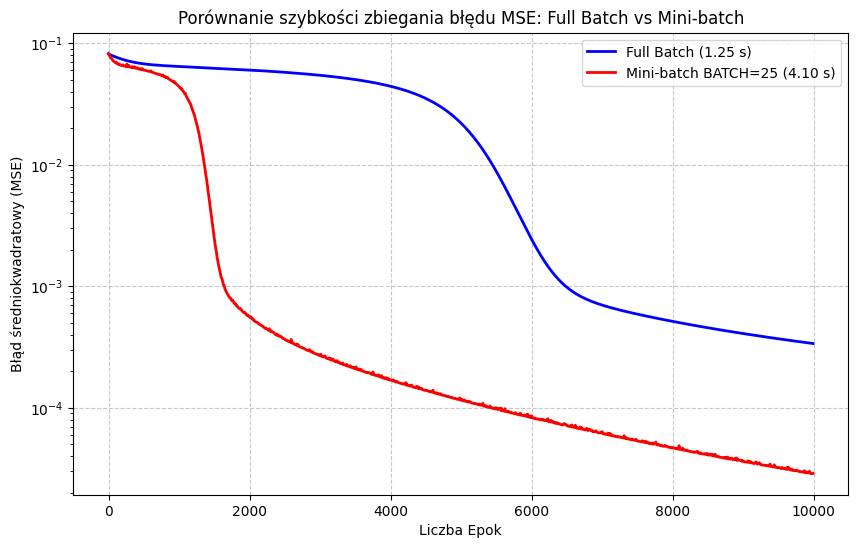

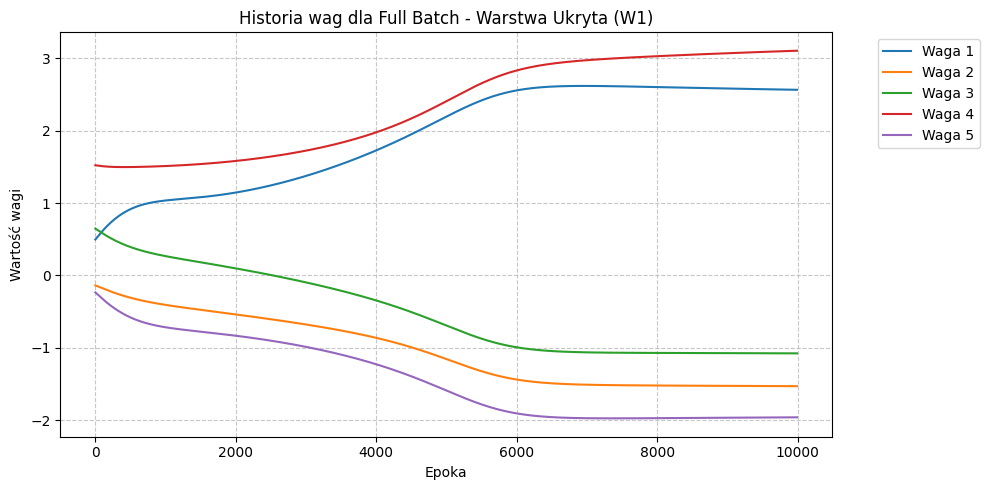

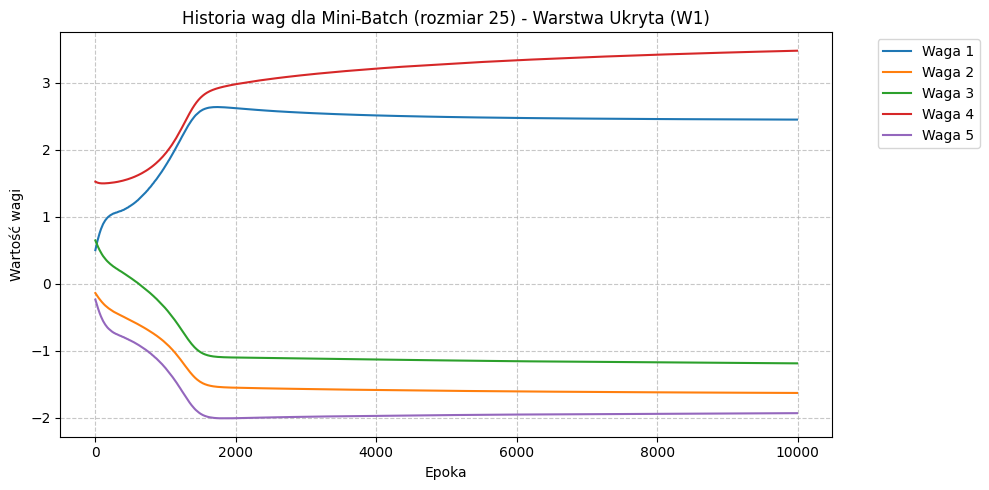

In [ ]:
EPOCHS = 10000
LEARNING_RATE = 0.1
BATCH_SIZE = 25
RECORD_INTERVAL = 10

np.random.seed(42)
mlp_full = MLP()
mlp_full.add_layer(DenseLayer(n_inputs=1, n_neurons=5, activation=Sigmoid(), init_method='random'))
mlp_full.add_layer(DenseLayer(n_inputs=5, n_neurons=5, activation=Sigmoid(), init_method='random'))
mlp_full.add_layer(DenseLayer(n_inputs=5, n_neurons=1, activation=Linear(), init_method='random'))

np.random.seed(42)
mlp_mini = MLP()
mlp_mini.add_layer(DenseLayer(n_inputs=1, n_neurons=5, activation=Sigmoid(), init_method='random'))
mlp_mini.add_layer(DenseLayer(n_inputs=5, n_neurons=5, activation=Sigmoid(), init_method='random'))
mlp_mini.add_layer(DenseLayer(n_inputs=5, n_neurons=1, activation=Linear(), init_method='random'))

print("Trening Full Batch rozpoczął się...")
loss_full_batch, weights_full, history_epochs, time_full = train_network(
    model=mlp_full, X=X_scaled, y=y_scaled, 
    epochs=EPOCHS, learning_rate=LEARNING_RATE, 
    batch_size=None, record_interval=RECORD_INTERVAL
)
print(f"Trening Full Batch zakończony. Czas: {time_full:.2f} s")

print("\nTrening Mini-Batch rozpoczął się...")
loss_mini_batch, weights_mini, _, time_mini = train_network(
    model=mlp_mini, X=X_scaled, y=y_scaled, 
    epochs=EPOCHS, learning_rate=LEARNING_RATE, 
    batch_size=BATCH_SIZE, record_interval=RECORD_INTERVAL
)
print(f"Trening Mini-Batch zakończony. Czas: {time_mini:.2f} s\n")

plt.figure(figsize=(10, 6))
plt.plot(history_epochs, loss_full_batch, label=f'Full Batch ({time_full:.2f} s)', color='blue', linewidth=2)
plt.plot(history_epochs, loss_mini_batch, label=f'Mini-batch BATCH={BATCH_SIZE} ({time_mini:.2f} s)', color='red', linewidth=2)

plt.title('Porównanie szybkości zbiegania błędu MSE: Full Batch vs Mini-batch')
plt.xlabel('Liczba Epok')
plt.ylabel('Błąd średniokwadratowy (MSE)')
plt.yscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plot_weight_history(history_epochs, weights_full, "Historia wag dla Full Batch - Warstwa Ukryta (W1)")
plot_weight_history(history_epochs, weights_mini, f"Historia wag dla Mini-Batch (rozmiar {BATCH_SIZE}) - Warstwa Ukryta (W1)")

In [49]:
X_test_scaled = scaler_X.transform(X_raw_test1)
preds_full_test_scaled = mlp_full.forward(X_test_scaled)
preds_mini_test_scaled = mlp_mini.forward(X_test_scaled)
preds_full_test_raw = scaler_y.inverse_transform(preds_full_test_scaled)
preds_mini_test_raw = scaler_y.inverse_transform(preds_mini_test_scaled)
mse_full_test_raw = np.mean((preds_full_test_raw - y_raw_test1) ** 2)
mse_mini_test_raw = np.mean((preds_mini_test_raw - y_raw_test1) ** 2)
print(f"Końcowe MSE na NIESKALOWANYM zbiorze testowym (Full Batch): {mse_full_test_raw:.4f}")
print(f"Końcowe MSE na NIESKALOWANYM zbiorze testowym (Mini-Batch): {mse_mini_test_raw:.4f}")

Końcowe MSE na NIESKALOWANYM zbiorze testowym (Full Batch): 35.0635
Końcowe MSE na NIESKALOWANYM zbiorze testowym (Mini-Batch): 3.3307


#### Mini Batch działa dłużej, ale daje lepsze rezultaty

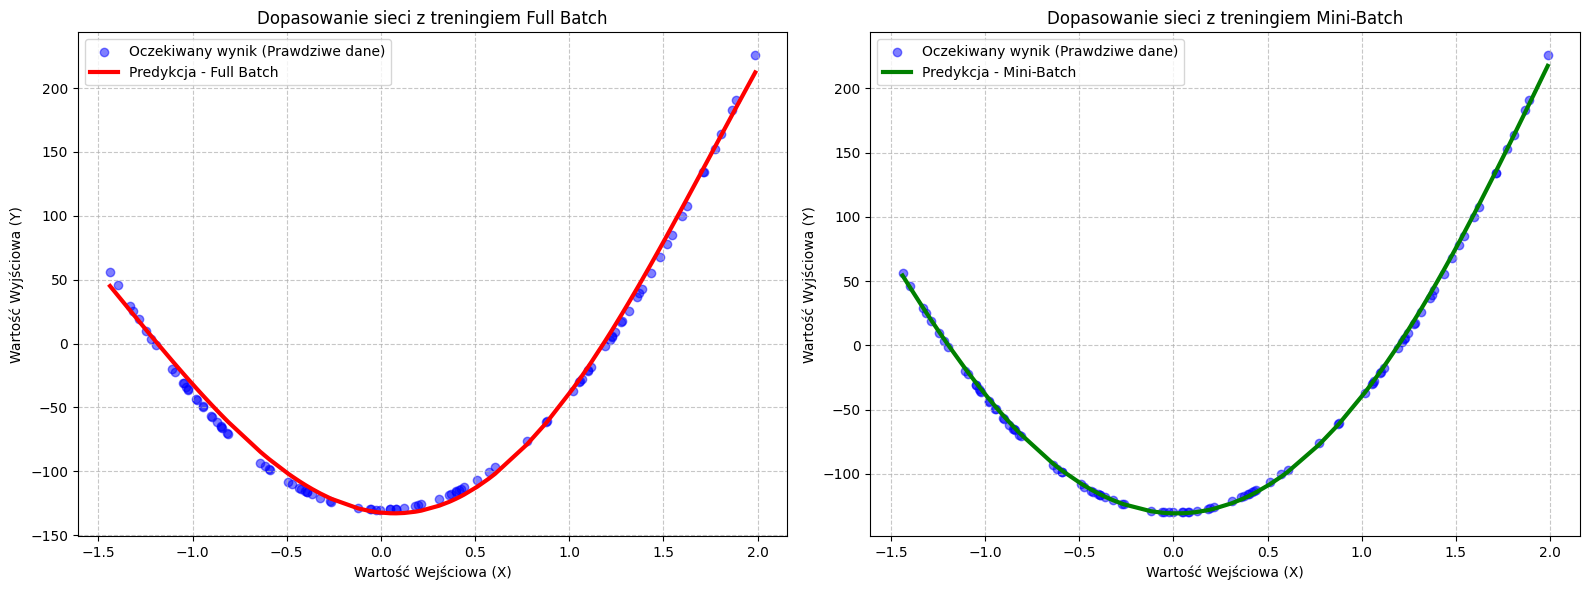

In [50]:
x_plot = X_raw_test1.flatten()
y_true_plot = y_raw_test1.flatten()
preds_full_plot = preds_full_test_raw.flatten()
preds_mini_plot = preds_mini_test_raw.flatten()

sorted_indices = np.argsort(x_plot)
x_plot_sorted = x_plot[sorted_indices]
y_true_sorted = y_true_plot[sorted_indices]
preds_full_sorted = preds_full_plot[sorted_indices]
preds_mini_sorted = preds_mini_plot[sorted_indices]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(x_plot_sorted, y_true_sorted, color='blue', alpha=0.5, label='Oczekiwany wynik (Prawdziwe dane)')
ax1.plot(x_plot_sorted, preds_full_sorted, color='red', linewidth=3, label='Predykcja - Full Batch')
ax1.set_title('Dopasowanie sieci z treningiem Full Batch')
ax1.set_xlabel('Wartość Wejściowa (X)')
ax1.set_ylabel('Wartość Wyjściowa (Y)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.scatter(x_plot_sorted, y_true_sorted, color='blue', alpha=0.5, label='Oczekiwany wynik (Prawdziwe dane)')
ax2.plot(x_plot_sorted, preds_mini_sorted, color='green', linewidth=3, label='Predykcja - Mini-Batch')
ax2.set_title('Dopasowanie sieci z treningiem Mini-Batch')
ax2.set_xlabel('Wartość Wejściowa (X)')
ax2.set_ylabel('Wartość Wyjściowa (Y)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### Dla architektury Sigmoid 1x5 nie było dobrego dopasowania (otrzymana była czasami funkcja liniowa). Podobnie dla ReLU nie udało się dopasować funkcji kwadratowej.
##### Dla architektury Sigmoid 2x5 dopasowanie jest nieco lepsze.

### Zbiór steps-large

In [8]:
df_train3 = pd.read_csv('steps-small-training.csv', index_col=0)
df_test3 = pd.read_csv('steps-small-test.csv', index_col=0)

In [9]:
X_raw_train3 = df_train3[['x']].values
y_raw_train3 = df_train3[['y']].values
X_raw_test3 = df_test3[['x']].values
y_raw_test3 = df_test3[['y']].values

In [10]:
scaler_X.fit(X_raw_train3)
scaler_y.fit(y_raw_train3)

X_scaled = scaler_X.transform(X_raw_train3)
y_scaled = scaler_y.transform(y_raw_train3)

Trening Full Batch rozpoczął się...
Trening Full Batch zakończony. Czas: 0.55 s

Trening Mini-Batch rozpoczął się...
Trening Mini-Batch zakończony. Czas: 1.06 s



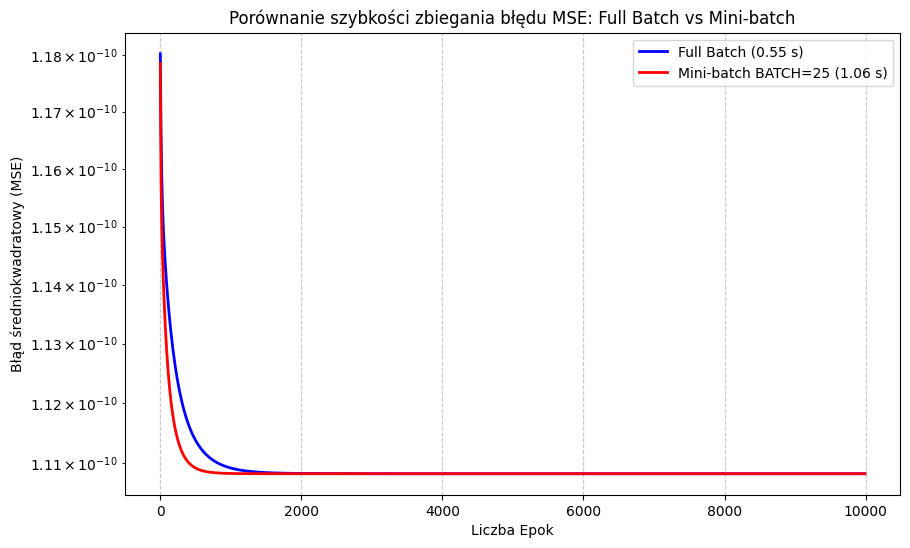

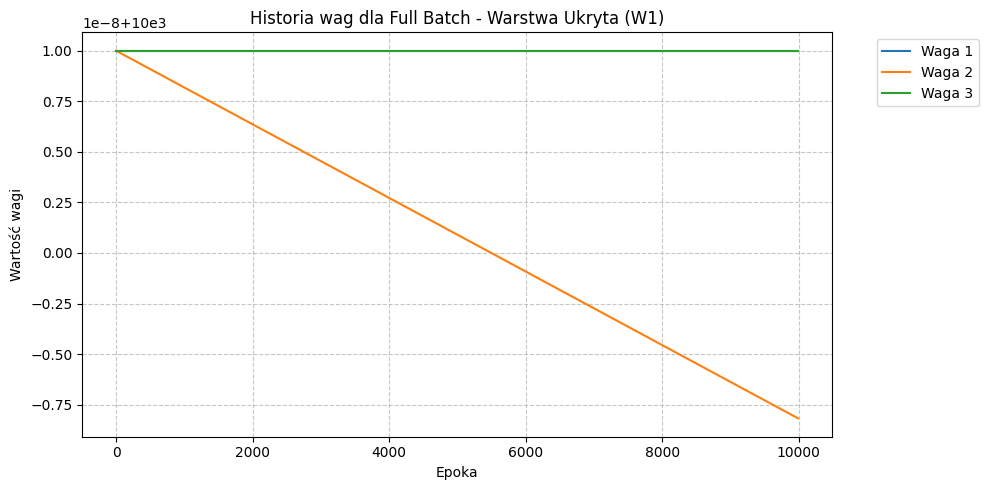

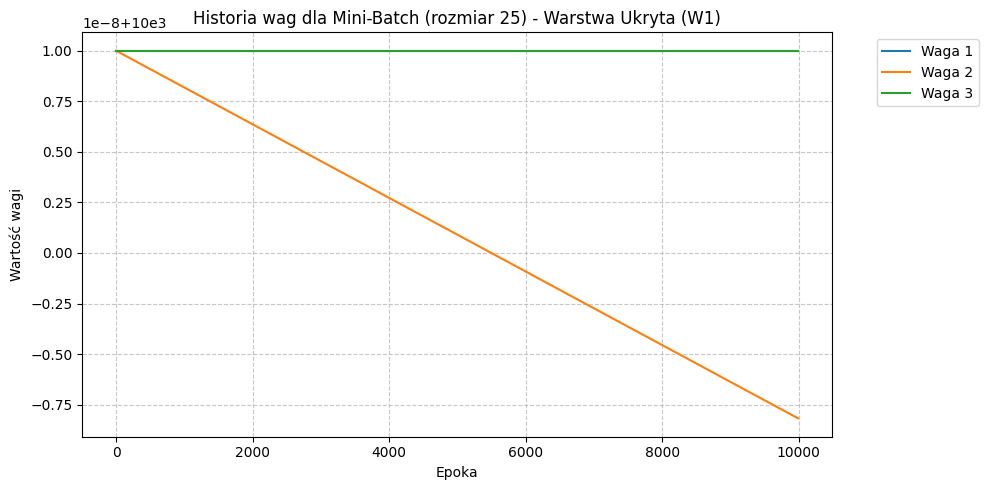

In [14]:
EPOCHS = 10000
LEARNING_RATE = 0.01
BATCH_SIZE = 25
RECORD_INTERVAL = 10

W1_manual = np.array([[10000.0, 10000.0, 10000.0]]) 
b1_manual = np.array([[5000.0, -5000.0, -15000.0]])   
W2_manual = np.array([[ 80.0],[80.0],[ 80.0]])
b2_manual = np.array([[-80.0]])

np.random.seed(42)
mlp_full = MLP()
mlp_full.add_layer(DenseLayer(n_inputs=1, n_neurons=3, activation=Sigmoid()))
mlp_full.add_layer(DenseLayer(n_inputs=3, n_neurons=1, activation=Linear()))

mlp_mini = MLP()
mlp_mini.add_layer(DenseLayer(n_inputs=1, n_neurons=3, activation=Sigmoid()))
mlp_mini.add_layer(DenseLayer(n_inputs=3, n_neurons=1, activation=Linear()))

# Ustawianie wag
mlp_full.layers[0].set_weights(W1_manual.copy(), b1_manual.copy())
mlp_mini.layers[0].set_weights(W1_manual.copy(), b1_manual.copy())
mlp_full.layers[1].set_weights(W2_manual.copy(), b2_manual.copy())
mlp_mini.layers[1].set_weights(W2_manual.copy(), b2_manual.copy())

print("Trening Full Batch rozpoczął się...")
loss_full_batch, weights_full, history_epochs, time_full = train_network(
    model=mlp_full, X=X_raw_train3, y=y_raw_train3, 
    epochs=EPOCHS, learning_rate=LEARNING_RATE, 
    batch_size=None, record_interval=RECORD_INTERVAL
)
print(f"Trening Full Batch zakończony. Czas: {time_full:.2f} s")

print("\nTrening Mini-Batch rozpoczął się...")
loss_mini_batch, weights_mini, _, time_mini = train_network(
    model=mlp_mini, X=X_raw_train3, y=y_raw_train3,  
    epochs=EPOCHS, learning_rate=LEARNING_RATE, 
    batch_size=BATCH_SIZE, record_interval=RECORD_INTERVAL
)
print(f"Trening Mini-Batch zakończony. Czas: {time_mini:.2f} s\n")

plt.figure(figsize=(10, 6))
plt.plot(history_epochs, loss_full_batch, label=f'Full Batch ({time_full:.2f} s)', color='blue', linewidth=2)
plt.plot(history_epochs, loss_mini_batch, label=f'Mini-batch BATCH={BATCH_SIZE} ({time_mini:.2f} s)', color='red', linewidth=2)

plt.title('Porównanie szybkości zbiegania błędu MSE: Full Batch vs Mini-batch')
plt.xlabel('Liczba Epok')
plt.ylabel('Błąd średniokwadratowy (MSE)')
plt.yscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plot_weight_history(history_epochs, weights_full, "Historia wag dla Full Batch - Warstwa Ukryta (W1)")
plot_weight_history(history_epochs, weights_mini, f"Historia wag dla Mini-Batch (rozmiar {BATCH_SIZE}) - Warstwa Ukryta (W1)")

#### Liczę nie na przeskalowanych danych, bo ustawiam wagi dla tych wartości (po obrazku)

In [15]:
preds_full_test_raw = mlp_full.forward(X_raw_test3)
preds_mini_test_raw = mlp_mini.forward(X_raw_test3)
mse_full_test_raw = np.mean((preds_full_test_raw - y_raw_test3) ** 2)
mse_mini_test_raw = np.mean((preds_mini_test_raw - y_raw_test3) ** 2)
print(f"Końcowe MSE na NIESKALOWANYM zbiorze testowym (Full Batch): {mse_full_test_raw:.4f}")
print(f"Końcowe MSE na NIESKALOWANYM zbiorze testowym (Mini-Batch): {mse_mini_test_raw:.4f}")

Końcowe MSE na NIESKALOWANYM zbiorze testowym (Full Batch): 0.0000
Końcowe MSE na NIESKALOWANYM zbiorze testowym (Mini-Batch): 0.0000


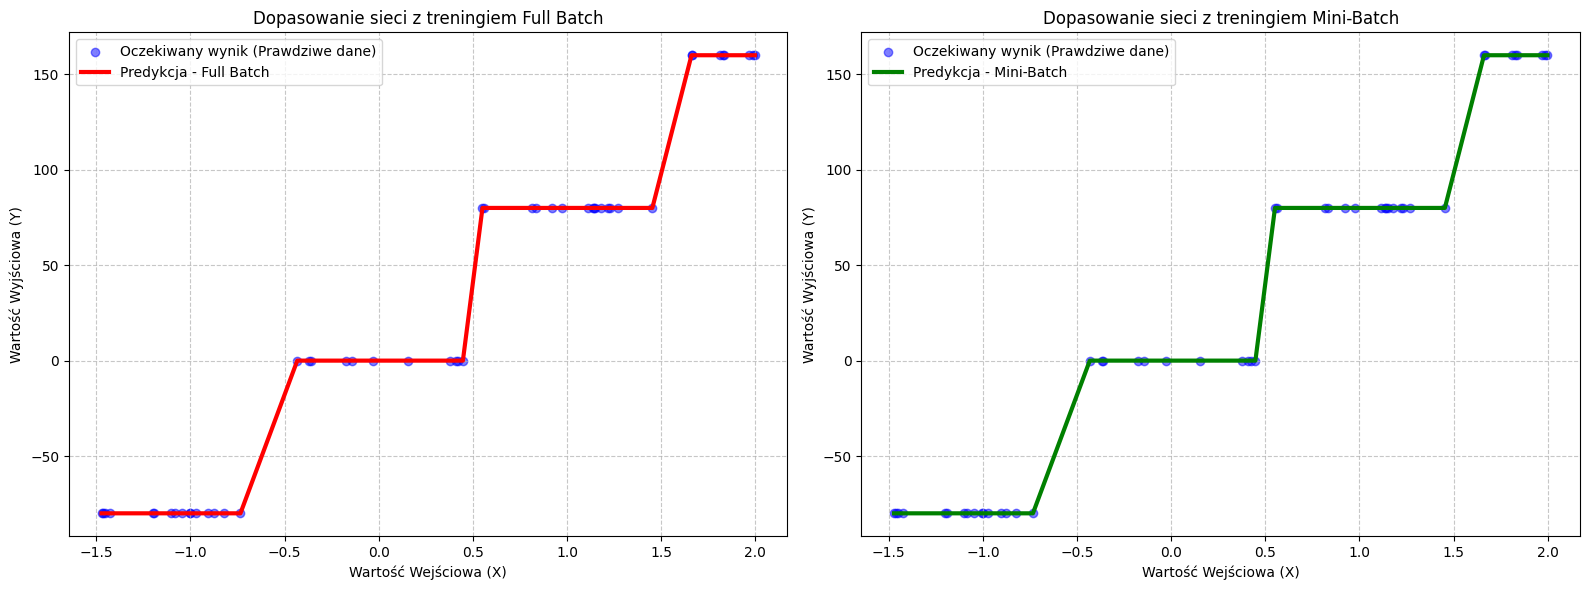

In [16]:
x_plot = X_raw_test3.flatten()
y_true_plot = y_raw_test3.flatten()
preds_full_plot = preds_full_test_raw.flatten()
preds_mini_plot = preds_mini_test_raw.flatten()

sorted_indices = np.argsort(x_plot)
x_plot_sorted = x_plot[sorted_indices]
y_true_sorted = y_true_plot[sorted_indices]
preds_full_sorted = preds_full_plot[sorted_indices]
preds_mini_sorted = preds_mini_plot[sorted_indices]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(x_plot_sorted, y_true_sorted, color='blue', alpha=0.5, label='Oczekiwany wynik (Prawdziwe dane)')
ax1.plot(x_plot_sorted, preds_full_sorted, color='red', linewidth=3, label='Predykcja - Full Batch')
ax1.set_title('Dopasowanie sieci z treningiem Full Batch')
ax1.set_xlabel('Wartość Wejściowa (X)')
ax1.set_ylabel('Wartość Wyjściowa (Y)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.scatter(x_plot_sorted, y_true_sorted, color='blue', alpha=0.5, label='Oczekiwany wynik (Prawdziwe dane)')
ax2.plot(x_plot_sorted, preds_mini_sorted, color='green', linewidth=3, label='Predykcja - Mini-Batch')
ax2.set_title('Dopasowanie sieci z treningiem Mini-Batch')
ax2.set_xlabel('Wartość Wejściowa (X)')
ax2.set_ylabel('Wartość Wyjściowa (Y)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Funkcja nie może się dopasować przez outlier, ale znacznie lepiej dopasowuje się niż przy losowej inicjalizacji wag.

### Zbiór mulitmodal - large

In [9]:
df_train4 = pd.read_csv('multimodal-large-training.csv', index_col=0)
df_test4 = pd.read_csv('multimodal-large-test.csv', index_col=0)
df_train4.reset_index(inplace=True)
df_test4.reset_index(inplace=True)

In [10]:
X_raw_train4 = df_train4[['x']].values
y_raw_train4 = df_train4[['y']].values
X_raw_test4 = df_test4[['x']].values
y_raw_test4 = df_test4[['y']].values

In [66]:
scaler_X.fit(X_raw_train4)
scaler_y.fit(y_raw_train4)

X_scaled = scaler_X.transform(X_raw_train4)
y_scaled = scaler_y.transform(y_raw_train4)

Trening Full Batch rozpoczął się...
Trening Full Batch zakończony. Czas: 90.68 s

Trening Mini-Batch rozpoczął się...
Trening Mini-Batch zakończony. Czas: 356.35 s



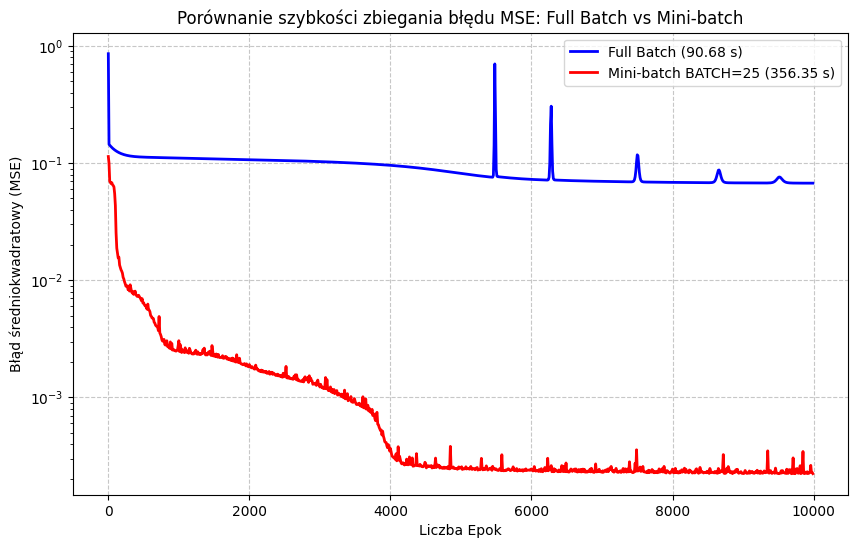

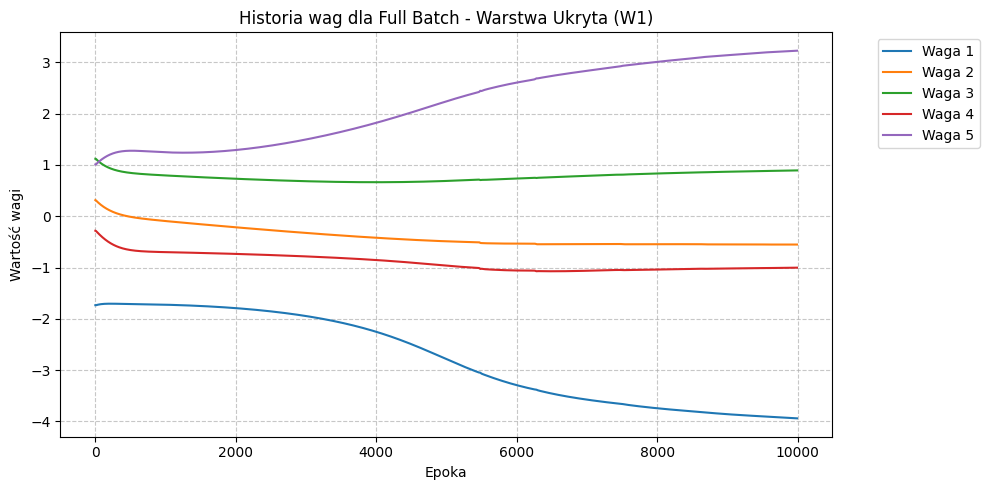

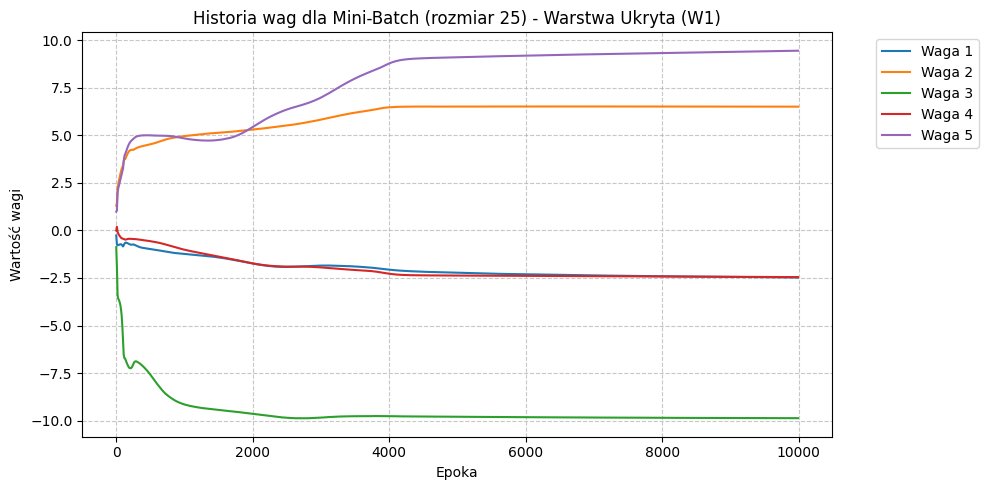

In [100]:
EPOCHS = 10000
LEARNING_RATE = 0.1
BATCH_SIZE = 25
RECORD_INTERVAL = 10

np.random.seed(100)
mlp_full = MLP()
mlp_full.add_layer(DenseLayer(n_inputs=1, n_neurons=5, activation=Sigmoid(), init_method='random'))
mlp_full.add_layer(DenseLayer(n_inputs=5, n_neurons=15, activation=Sigmoid(), init_method='random'))
mlp_full.add_layer(DenseLayer(n_inputs=15, n_neurons=10, activation=Sigmoid(), init_method='random'))
mlp_full.add_layer(DenseLayer(n_inputs=10, n_neurons=1, activation=Linear(), init_method='random'))

mlp_mini = MLP()
mlp_mini.add_layer(DenseLayer(n_inputs=1, n_neurons=5, activation=Sigmoid(), init_method='random'))
mlp_mini.add_layer(DenseLayer(n_inputs=5, n_neurons=15, activation=Sigmoid(), init_method='random'))
mlp_mini.add_layer(DenseLayer(n_inputs=15, n_neurons=10, activation=Sigmoid(), init_method='random'))
mlp_mini.add_layer(DenseLayer(n_inputs=10, n_neurons=1, activation=Linear(), init_method='random'))

print("Trening Full Batch rozpoczął się...")
loss_full_batch, weights_full, history_epochs, time_full = train_network(
    model=mlp_full, X=X_scaled, y=y_scaled, 
    epochs=EPOCHS, learning_rate=LEARNING_RATE, 
    batch_size=None, record_interval=RECORD_INTERVAL
)
print(f"Trening Full Batch zakończony. Czas: {time_full:.2f} s")

print("\nTrening Mini-Batch rozpoczął się...")
loss_mini_batch, weights_mini, _, time_mini = train_network(
    model=mlp_mini, X=X_scaled, y=y_scaled, 
    epochs=EPOCHS, learning_rate=LEARNING_RATE, 
    batch_size=BATCH_SIZE, record_interval=RECORD_INTERVAL
)
print(f"Trening Mini-Batch zakończony. Czas: {time_mini:.2f} s\n")

plt.figure(figsize=(10, 6))
plt.plot(history_epochs, loss_full_batch, label=f'Full Batch ({time_full:.2f} s)', color='blue', linewidth=2)
plt.plot(history_epochs, loss_mini_batch, label=f'Mini-batch BATCH={BATCH_SIZE} ({time_mini:.2f} s)', color='red', linewidth=2)

plt.title('Porównanie szybkości zbiegania błędu MSE: Full Batch vs Mini-batch')
plt.xlabel('Liczba Epok')
plt.ylabel('Błąd średniokwadratowy (MSE)')
plt.yscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plot_weight_history(history_epochs, weights_full, "Historia wag dla Full Batch - Warstwa Ukryta (W1)")
plot_weight_history(history_epochs, weights_mini, f"Historia wag dla Mini-Batch (rozmiar {BATCH_SIZE}) - Warstwa Ukryta (W1)")

In [101]:
X_test_scaled = scaler_X.transform(X_raw_test4)
preds_full_test_scaled = mlp_full.forward(X_test_scaled)
preds_mini_test_scaled = mlp_mini.forward(X_test_scaled)
preds_full_test_raw = scaler_y.inverse_transform(preds_full_test_scaled)
preds_mini_test_raw = scaler_y.inverse_transform(preds_mini_test_scaled)
mse_full_test_raw = np.mean((preds_full_test_raw - y_raw_test4) ** 2)
mse_mini_test_raw = np.mean((preds_mini_test_raw - y_raw_test4) ** 2)
print(f"Końcowe MSE na NIESKALOWANYM zbiorze testowym (Full Batch): {mse_full_test_raw:.4f}")
print(f"Końcowe MSE na NIESKALOWANYM zbiorze testowym (Mini-Batch): {mse_mini_test_raw:.4f}")

Końcowe MSE na NIESKALOWANYM zbiorze testowym (Full Batch): 2635.5409
Końcowe MSE na NIESKALOWANYM zbiorze testowym (Mini-Batch): 4.6778


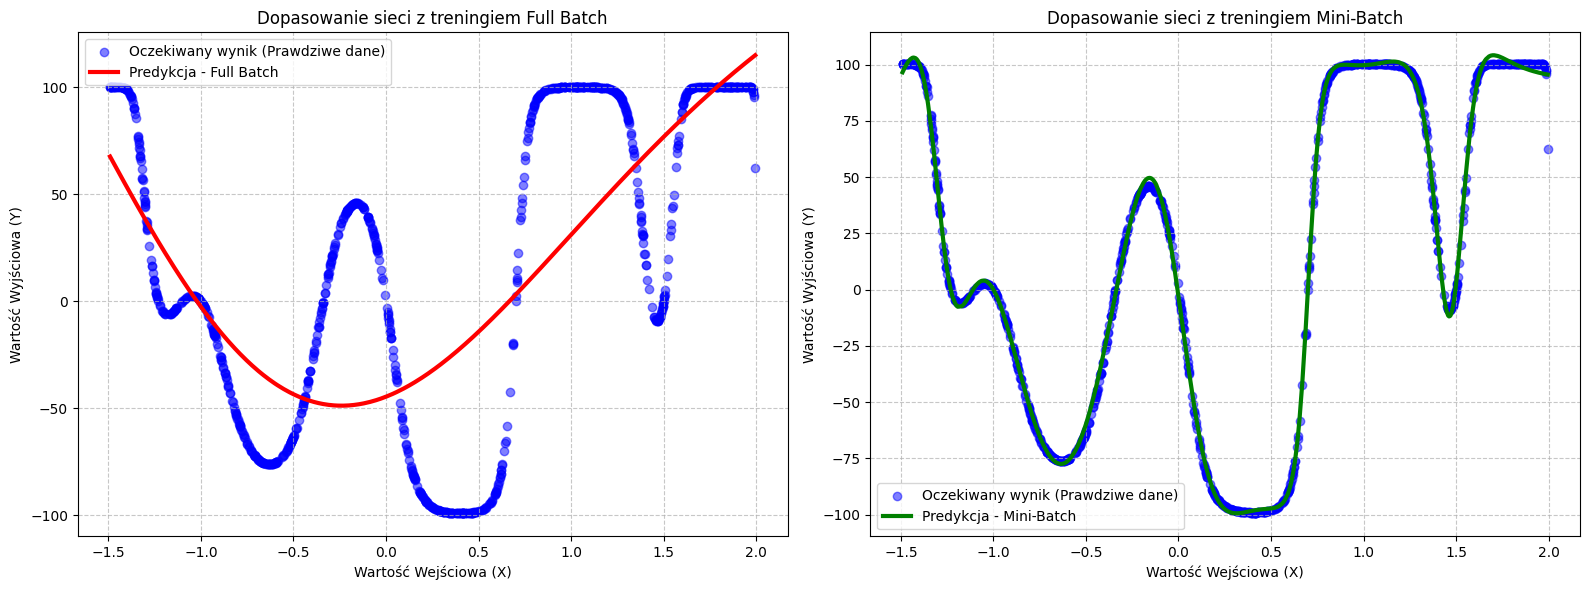

In [102]:
x_plot = X_raw_test4.flatten()
y_true_plot = y_raw_test4.flatten()
preds_full_plot = preds_full_test_raw.flatten()
preds_mini_plot = preds_mini_test_raw.flatten()

sorted_indices = np.argsort(x_plot)
x_plot_sorted = x_plot[sorted_indices]
y_true_sorted = y_true_plot[sorted_indices]
preds_full_sorted = preds_full_plot[sorted_indices]
preds_mini_sorted = preds_mini_plot[sorted_indices]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(x_plot_sorted, y_true_sorted, color='blue', alpha=0.5, label='Oczekiwany wynik (Prawdziwe dane)')
ax1.plot(x_plot_sorted, preds_full_sorted, color='red', linewidth=3, label='Predykcja - Full Batch')
ax1.set_title('Dopasowanie sieci z treningiem Full Batch')
ax1.set_xlabel('Wartość Wejściowa (X)')
ax1.set_ylabel('Wartość Wyjściowa (Y)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.scatter(x_plot_sorted, y_true_sorted, color='blue', alpha=0.5, label='Oczekiwany wynik (Prawdziwe dane)')
ax2.plot(x_plot_sorted, preds_mini_sorted, color='green', linewidth=3, label='Predykcja - Mini-Batch')
ax2.set_title('Dopasowanie sieci z treningiem Mini-Batch')
ax2.set_xlabel('Wartość Wejściowa (X)')
ax2.set_ylabel('Wartość Wyjściowa (Y)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### Dla Batch-size mniejszego niż 100 dla liczby epok równej 10000 sieć uczy się dłużej niż w full batch, jednak dla większego batch size ten czas jest krótszy

##### Dopiero dla bardzo małego batch size sieć się dopasowuje

## NN3

In [7]:
np.random.seed(42)
datasets = {
    "square-large": {
        "train": pd.read_csv('square-large-training.csv', index_col=0),
        "test": pd.read_csv('square-large-test.csv', index_col=0)
    },
    "steps-large": {
        "train": pd.read_csv('steps-large-training.csv', index_col=0),
        "test": pd.read_csv('steps-large-test.csv', index_col=0)
    },
    "multimodal-large": {
        "train": pd.read_csv('multimodal-large-training.csv', index_col=0),
        "test": pd.read_csv('multimodal-large-test.csv', index_col=0)
    }
}

In [8]:
def plot_single_optimization(X_raw, y_raw, preds_raw, dataset_name, optimizer_name):
    mse = mean_squared_error(y_raw, preds_raw)
    x_plot = X_raw.flatten()
    y_true_plot = y_raw.flatten()
    preds_plot = preds_raw.flatten()
    sorted_indices = np.argsort(x_plot)
    x_sorted = x_plot[sorted_indices]
    y_sorted = y_true_plot[sorted_indices]
    preds_sorted = preds_plot[sorted_indices]
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle(f'Eksperyment na zbiorze: {dataset_name}', fontsize=16)
    ax.scatter(x_sorted, y_sorted, color='blue', alpha=0.3, label='Dane prawdziwe')
    color = 'red' if optimizer_name == 'Momentum' else 'green'
    ax.plot(x_sorted, preds_sorted, color=color, linewidth=3, label=f'{optimizer_name} (MSE: {mse:.4f})')
    
    ax.set_title(f'Dopasowanie: {optimizer_name}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [9]:
def compare_optimizers(dataset_name, optimizer='Momentum', epochs=10000, lr=0.01,
                        hidden_arch=[10, 10], mom=0, rms=0, batch_size=25, activation = "sigmoid"):
    plot_color = 'red'
    if optimizer.lower() == 'rmsprop':
        plot_color = 'green'
    if optimizer.lower() == 'momentum' and mom == 0 and rms == 0:
        mom, rms = 0.9, 0.0
    elif optimizer.lower() == 'rmsprop' and mom == 0 and rms == 0:
        mom, rms = 0.0, 0.9
        plot_color = 'green'
    df_train = datasets[dataset_name]["train"]
    X_train_raw = df_train[['x']].values
    y_train_raw = df_train[['y']].values

    sc_x = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_train_scaled = sc_x.fit_transform(X_train_raw)
    y_train_scaled = sc_y.fit_transform(y_train_raw)
    
    df_test = datasets[dataset_name]["test"]
    X_test_raw = df_test[['x']].values
    y_test_raw = df_test[['y']].values
    X_test_scaled = sc_x.transform(X_test_raw)

    model = MLP()
    if activation == "sigmoid":
        model.add_layer(DenseLayer(1, hidden_arch[0], Sigmoid(), init_method='random'))
    elif activation == "relu":
        model.add_layer(DenseLayer(1, hidden_arch[0], ReLU(), init_method='random'))
    elif activation == "tanh":
        model.add_layer(DenseLayer(1, hidden_arch[0], Tanh(), init_method='random'))
    for i in range(len(hidden_arch)-1):
        if activation == "sigmoid":
            model.add_layer(DenseLayer(hidden_arch[i], hidden_arch[i+1], Sigmoid(), init_method='random'))
        elif activation == "relu":
            model.add_layer(DenseLayer(hidden_arch[i], hidden_arch[i+1], ReLU(), init_method='random'))
        elif activation == "tanh":
            model.add_layer(DenseLayer(hidden_arch[i], hidden_arch[i+1], Tanh(), init_method='random'))
    model.add_layer(DenseLayer(hidden_arch[-1], 1, Linear(), init_method='random'))
    loss_history, _, _, exec_time = train_network(
        model, X_train_scaled, y_train_scaled, epochs, lr, batch_size=batch_size, 
        momentum=mom, rmsprop_beta=rms
    )
    preds_norm = model.forward(X_test_scaled)
    preds_raw = sc_y.inverse_transform(preds_norm)
    mse = mean_squared_error(y_test_raw, preds_raw)

    fig, ax1 = plt.subplots(figsize=(16, 5))
    fig.suptitle(f'Wyniki dla: {optimizer} | Zbiór: {dataset_name}', fontsize=16)
    ax1.plot(loss_history, label=f"Czas: {exec_time:.2f}s", color=plot_color)
    ax1.set_title("Zbieżność (Training Loss)")
    ax1.set_xlabel("Próbka kontrolna")
    ax1.set_ylabel("MSE Znormalizowane")
    ax1.set_yscale('log')
    ax1.legend()
    ax1.grid(True)

    plot_single_optimization(X_test_raw, y_test_raw, preds_raw, dataset_name, optimizer)

    print(f"\n--- RAPORT KOŃCOWY (TEST MSE) DLA {dataset_name} ---")
    mse = mean_squared_error(y_test_raw, preds_raw)
    print(f"{optimizer} -> MSE TESTOWE: {mse:.4f}")

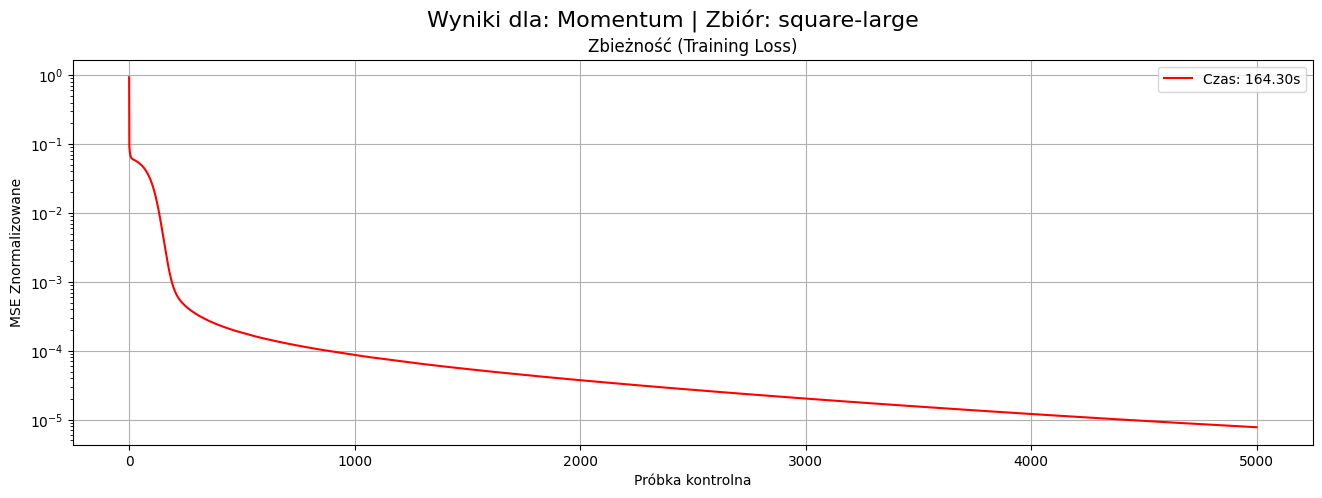

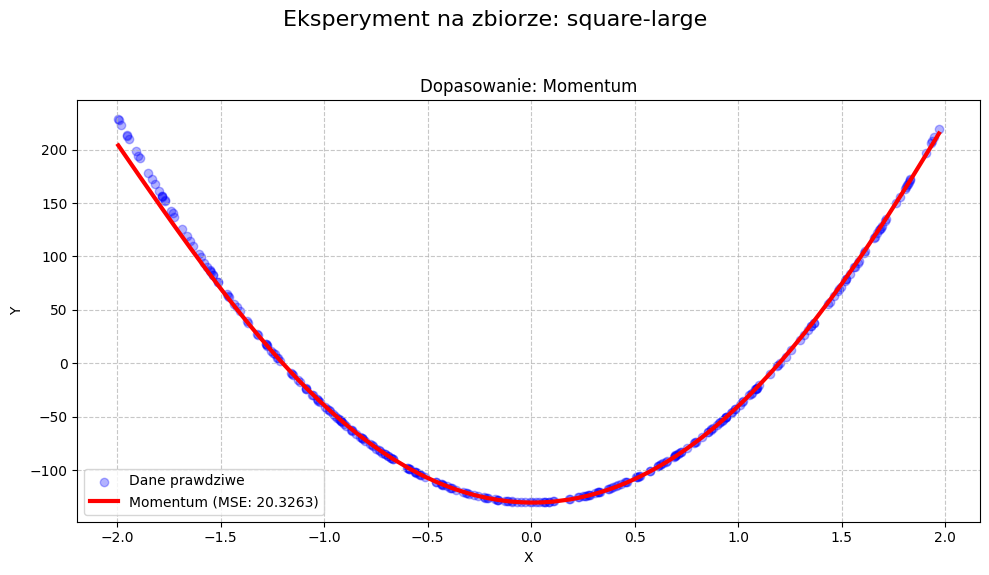


--- RAPORT KOŃCOWY (TEST MSE) DLA square-large ---
Momentum -> MSE TESTOWE: 20.3263


In [16]:
compare_optimizers("square-large", epochs=50000, lr=0.001, hidden_arch=[32, 16], optimizer='Momentum', mom = 0.9, batch_size=100, activation="sigmoid")

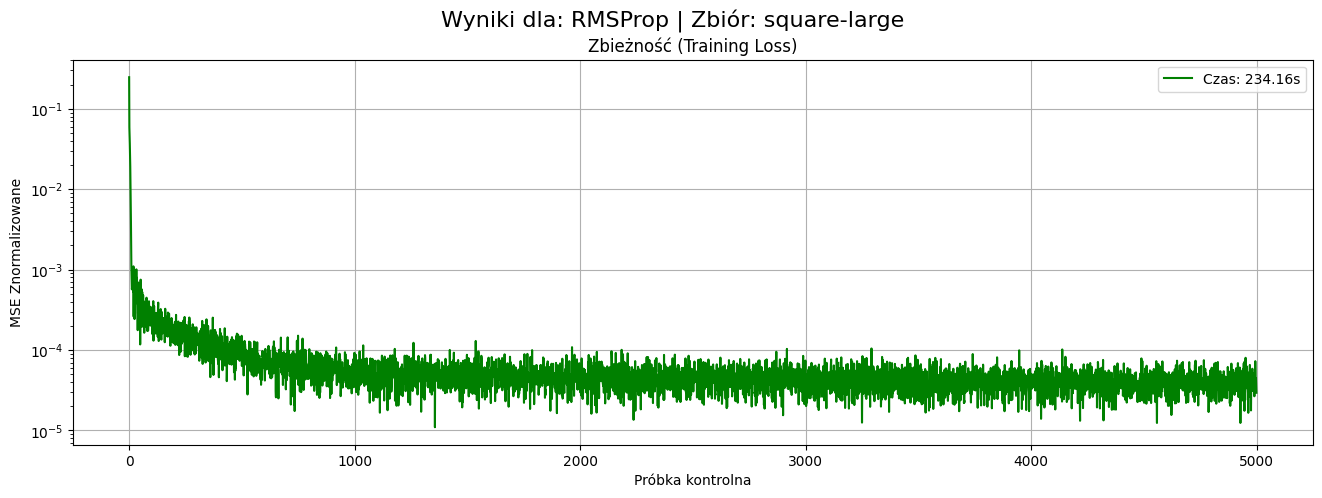

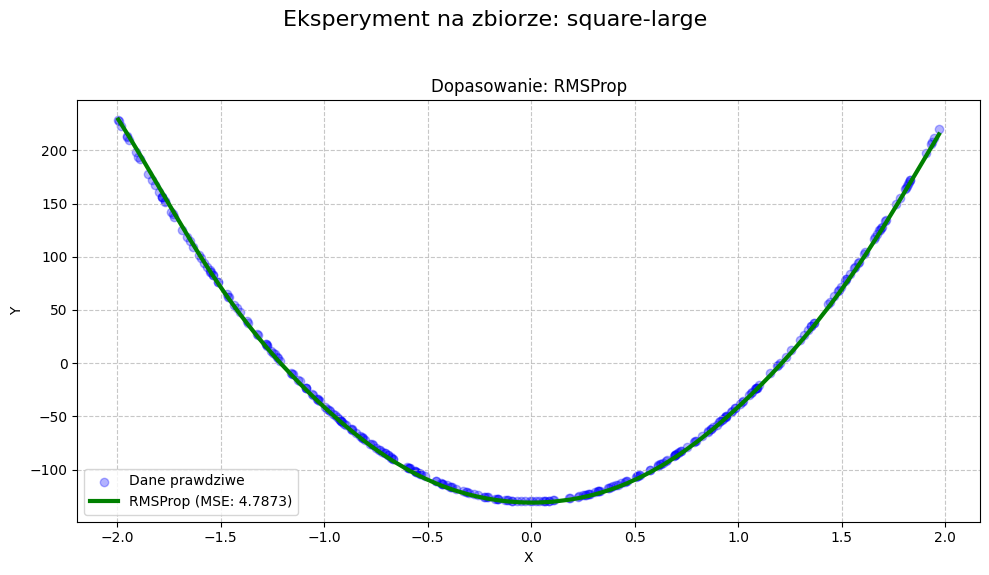


--- RAPORT KOŃCOWY (TEST MSE) DLA square-large ---
RMSProp -> MSE TESTOWE: 4.7873


In [ ]:
compare_optimizers("square-large", epochs=50000, lr=0.001, hidden_arch=[32, 16], optimizer='RMSProp', rms = 0.9, batch_size=100)

#### RMSProp ma mniej stabilną funkcję straty, ale lepiej zbiega

#### Test obu dla większych współczynników uczenia

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


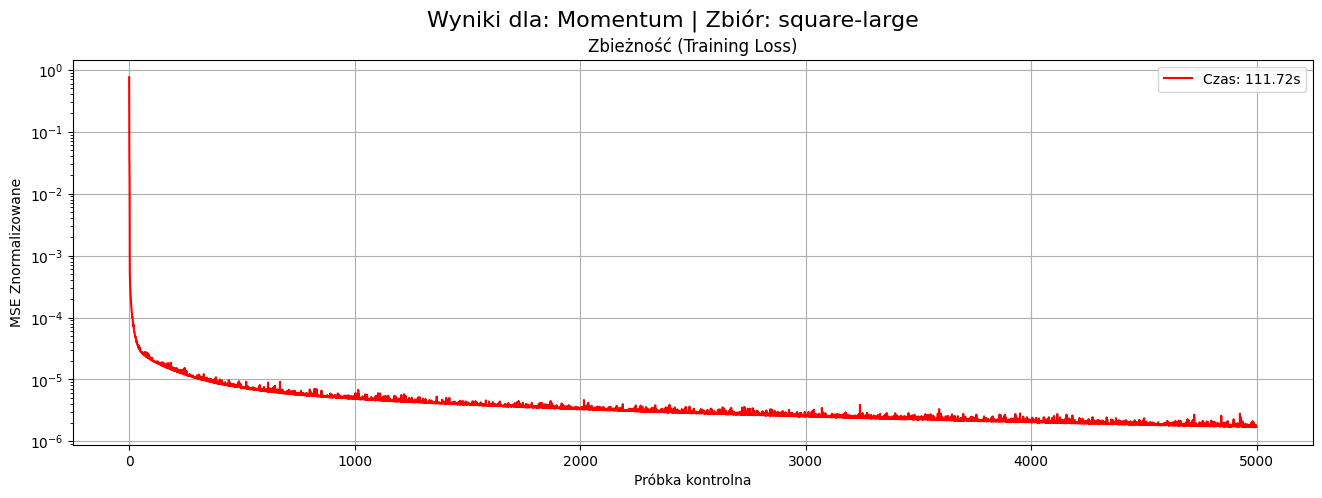

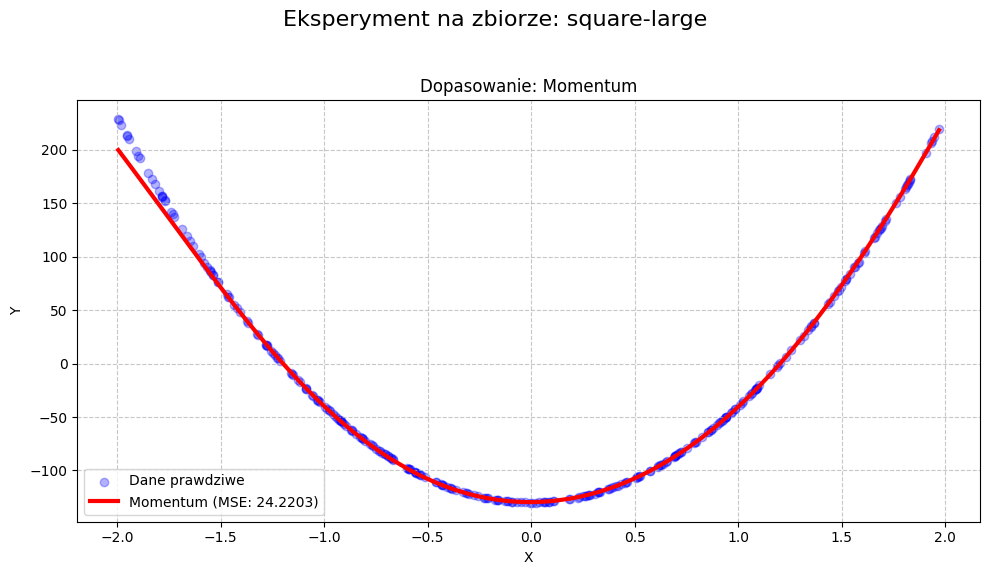


--- RAPORT KOŃCOWY (TEST MSE) DLA square-large ---
Momentum -> MSE TESTOWE: 24.2203


In [17]:
compare_optimizers("square-large", epochs=50000, lr=0.1, hidden_arch=[32, 16], optimizer='Momentum', mom = 0.9, batch_size=100, activation="sigmoid")

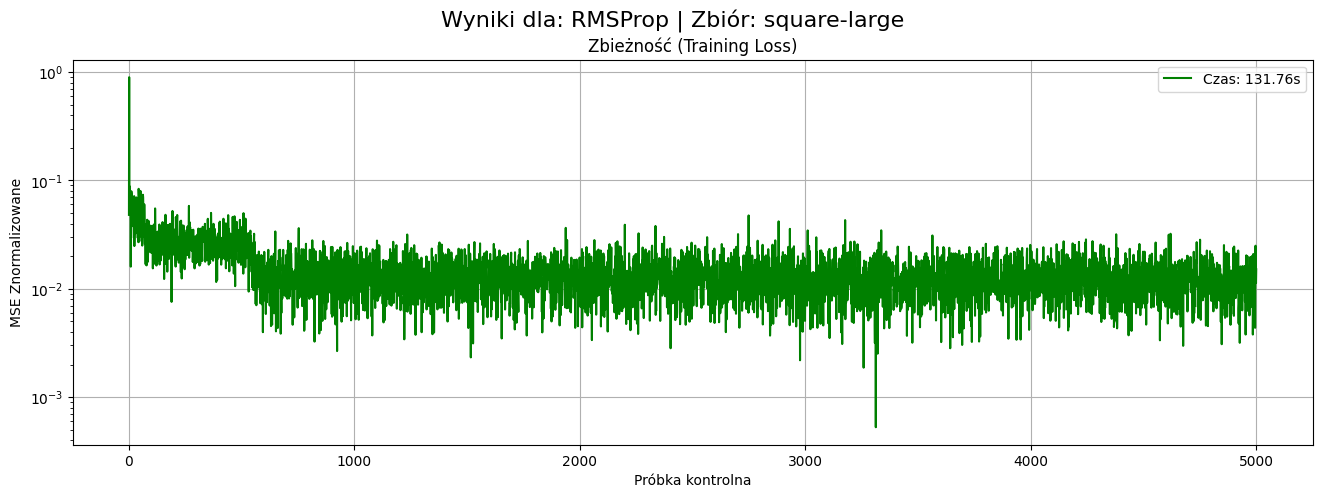

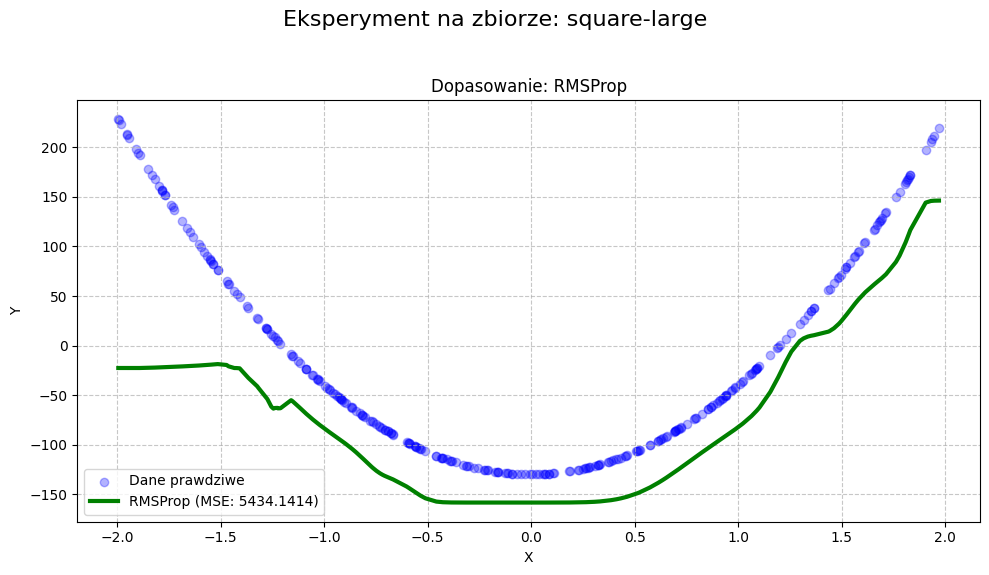


--- RAPORT KOŃCOWY (TEST MSE) DLA square-large ---
RMSProp -> MSE TESTOWE: 5434.1414


In [18]:
compare_optimizers("square-large", epochs=50000, lr=0.1, hidden_arch=[32, 16], optimizer='RMSProp', rms = 0.9, batch_size=100)

#### RMSProp radzi sobie znacznie gorzej z większym współczynnkiem uczenia

#### Test dla większych wartości praametrów momentum i rms dla współczynników uczenia które wyszły lepiej

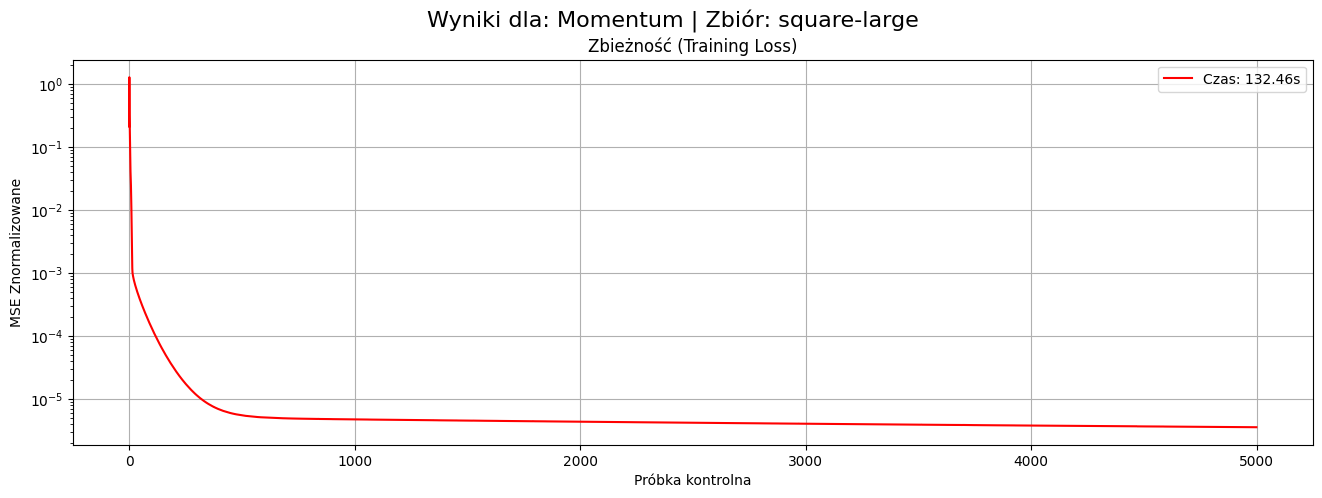

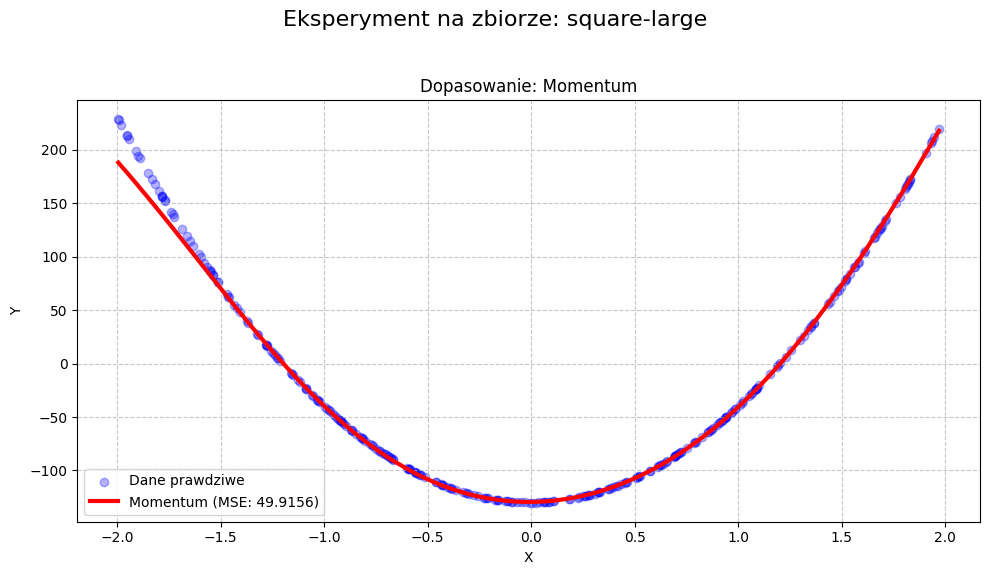


--- RAPORT KOŃCOWY (TEST MSE) DLA square-large ---
Momentum -> MSE TESTOWE: 49.9156


In [11]:
compare_optimizers("square-large", epochs=50000, lr=0.001, hidden_arch=[32, 16], optimizer='Momentum', mom = 0.99, batch_size=100, activation="sigmoid")

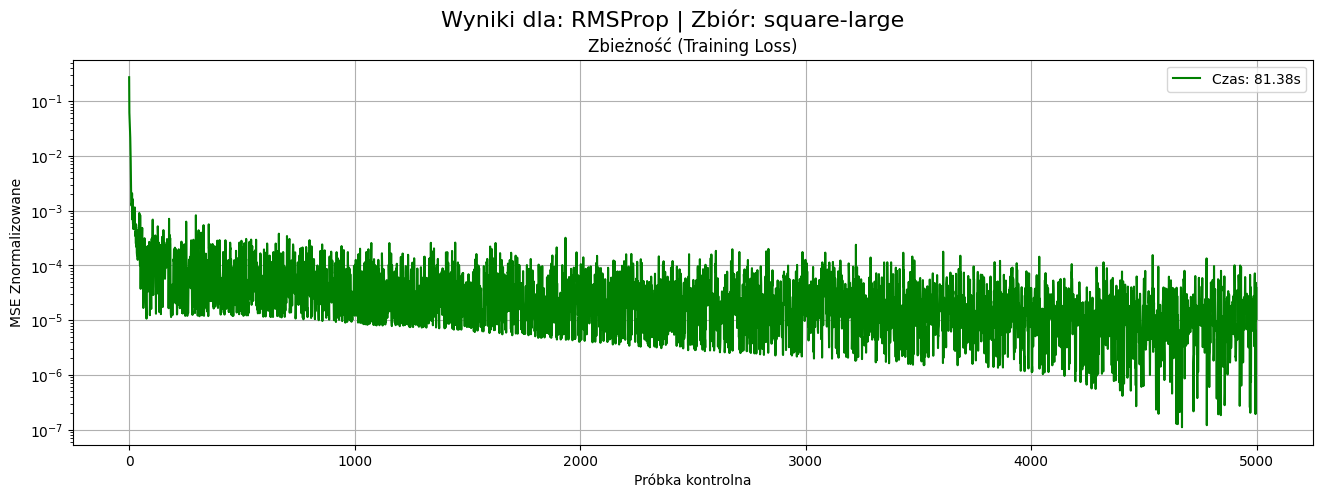

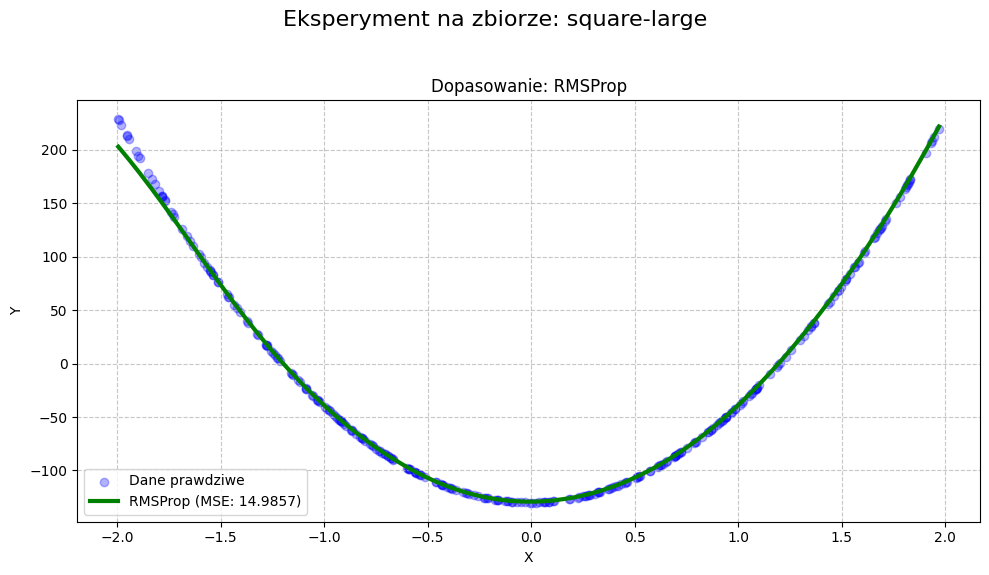


--- RAPORT KOŃCOWY (TEST MSE) DLA square-large ---
RMSProp -> MSE TESTOWE: 14.9857


In [12]:
compare_optimizers("square-large", epochs=50000, lr=0.001, hidden_arch=[32, 16], optimizer='RMSProp', rms = 0.99, batch_size=100, activation="sigmoid")

#### Zbiór ze schodami

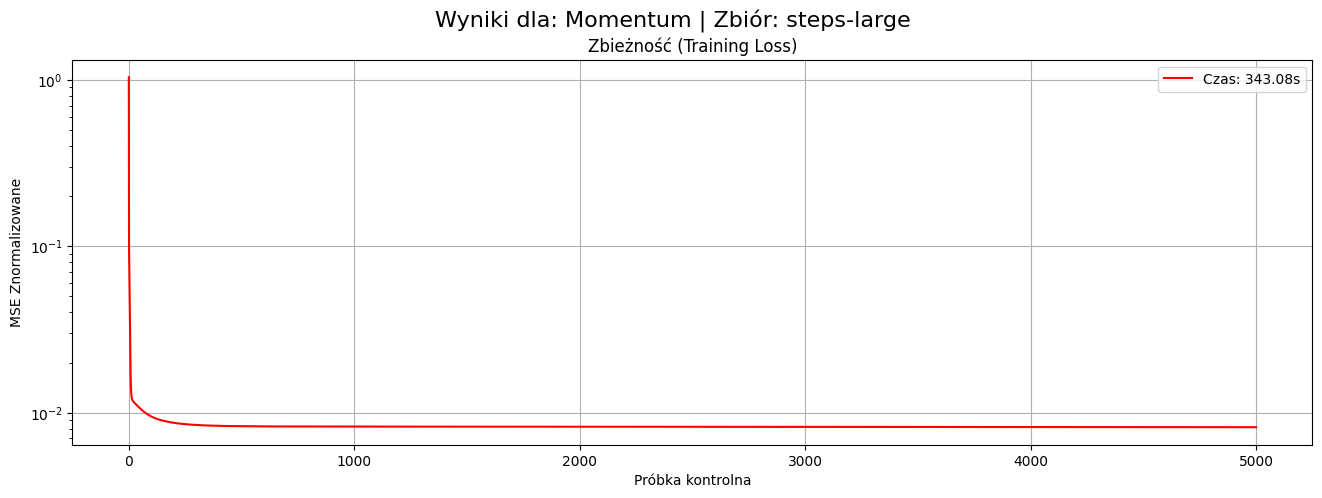

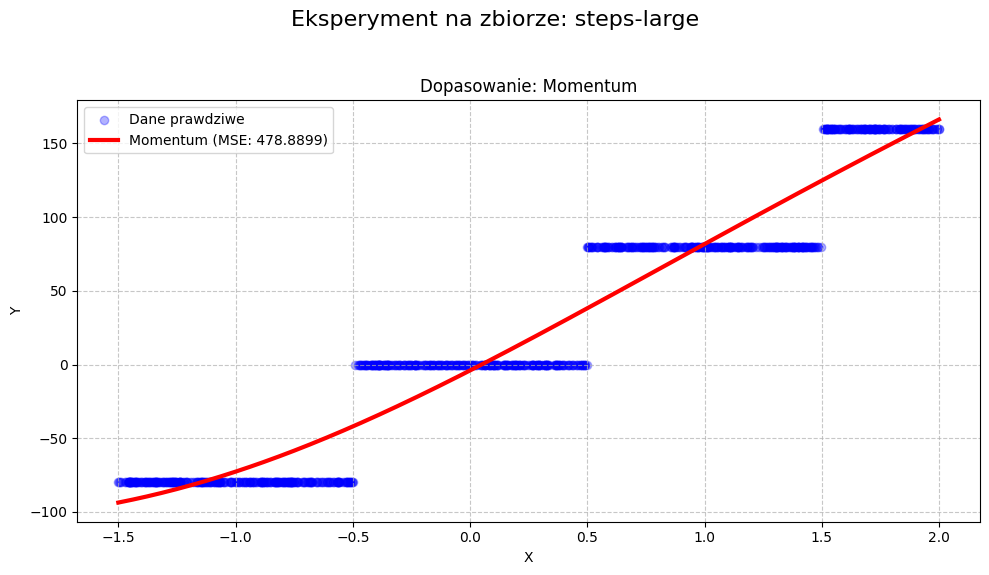


--- RAPORT KOŃCOWY (TEST MSE) DLA steps-large ---
Momentum -> MSE TESTOWE: 478.8899


In [13]:
compare_optimizers("steps-large", epochs=50000, lr=0.001, hidden_arch=[32, 16], optimizer='Momentum', mom = 0.9, batch_size=1000)

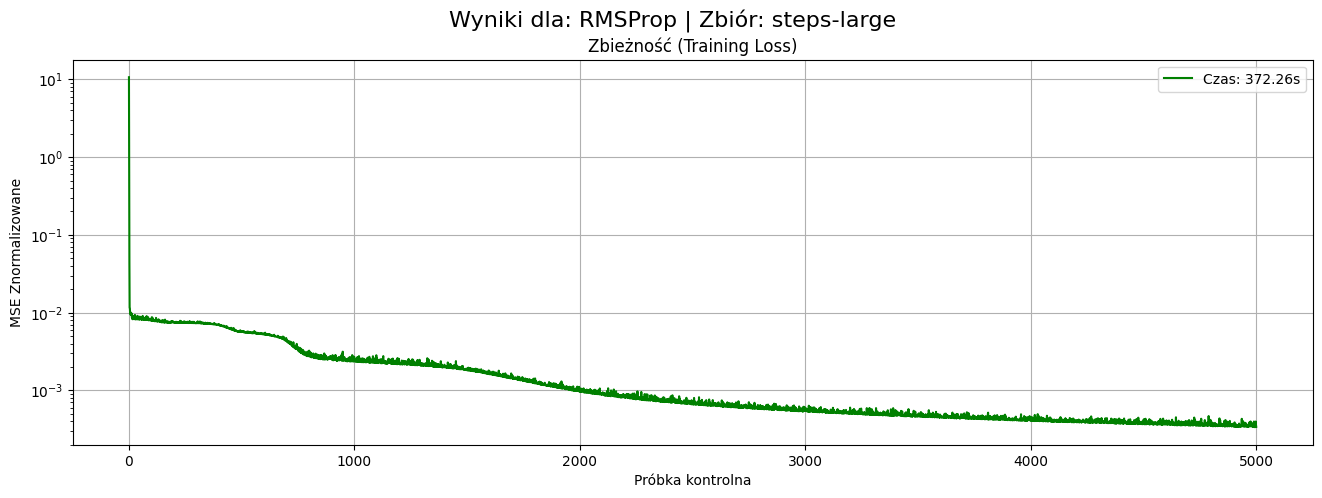

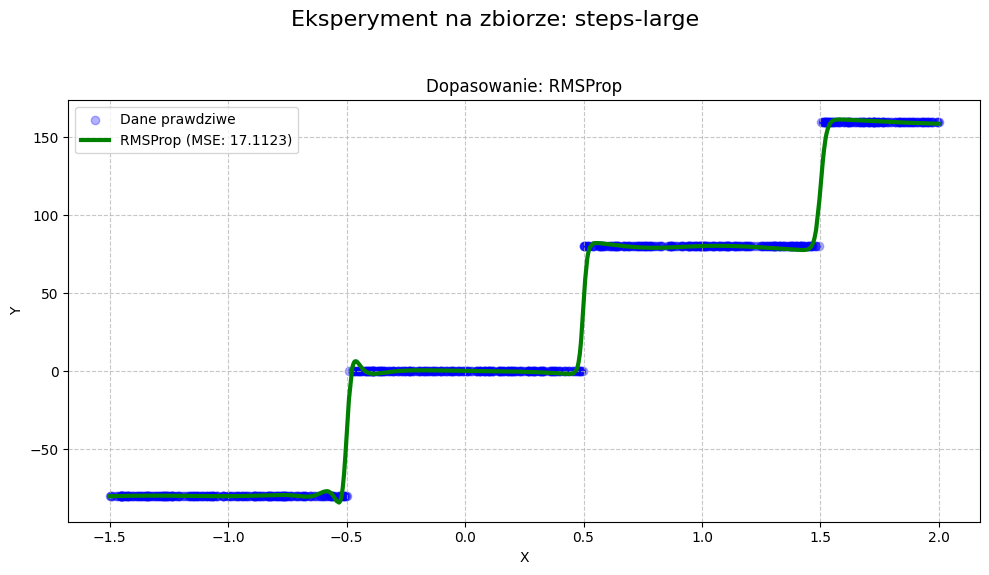


--- RAPORT KOŃCOWY (TEST MSE) DLA steps-large ---
RMSProp -> MSE TESTOWE: 17.1123


In [14]:
compare_optimizers("steps-large", epochs=50000, lr=0.001, hidden_arch=[32, 16], optimizer='RMSProp', rms=0.9, batch_size=1000)

#### Minima są z grubsza znalezione, trening jest bardziej stabilny

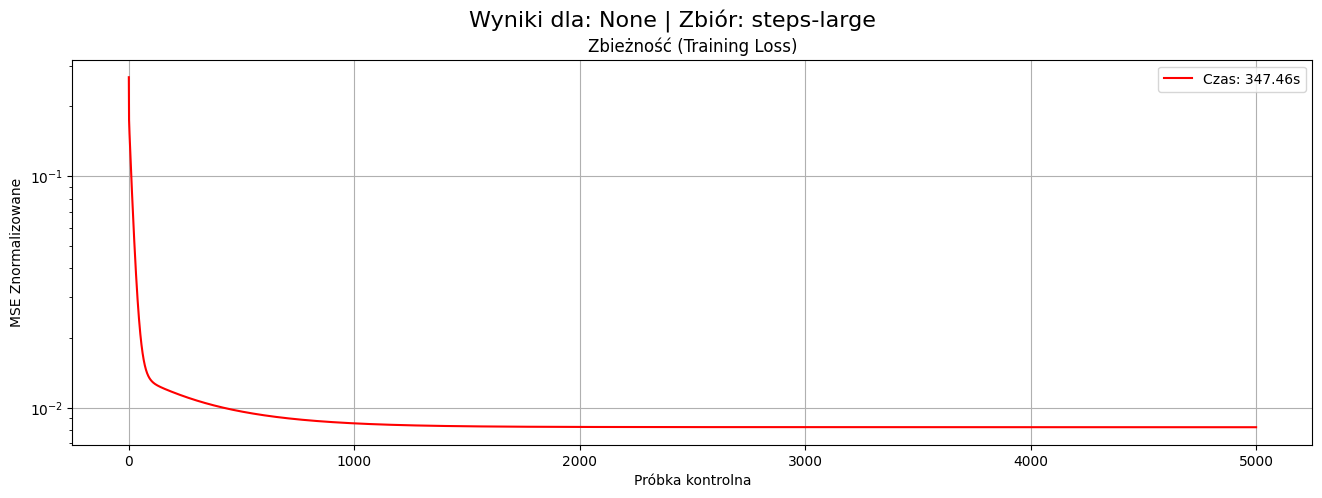

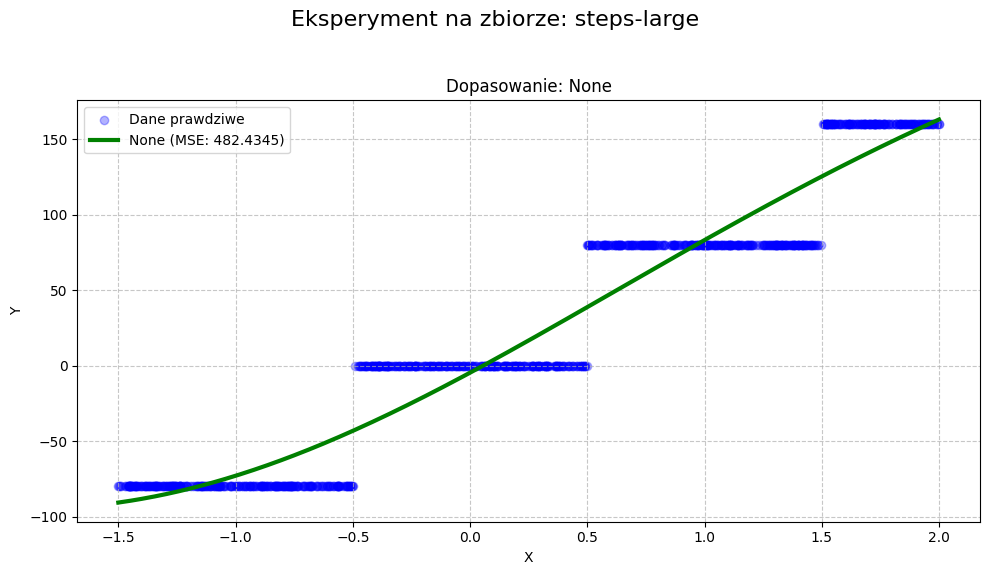


--- RAPORT KOŃCOWY (TEST MSE) DLA steps-large ---
None -> MSE TESTOWE: 482.4345


In [16]:
compare_optimizers("steps-large", epochs=50000, lr=0.001, hidden_arch=[32, 16], optimizer="None", batch_size=1000)

##### Momentum z powyższymi parametrami prawie nic nie dało w porównaniu do setupu z brakiem uzywania optimizera

In [ ]:
compare_optimizers("multimodal-large", epochs=10000, lr=0.1, hidden_arch=[5, 15, 10])